# ISOKANN + AMORE vs CellRank 2 / GPCCA — MEF reprogramming (CR2 RealTimeKernel)

**What this is.** A single, self-contained benchmark of the *plug-in Koopman* arm of
ISOKANN+AMORE ("Arm K") against CellRank 2's GPCCA estimator on the **mouse-embryonic-fibroblast (MEF)
reprogramming** dataset (Schiebinger et al. 2019), the RealTimeKernel "mef" analysis of the CellRank 2
paper (Nature Methods 2024). Both methods consume the **identical** published RealTimeKernel transition
matrix `T` (shipped with the serum subset, WOT-based), the identical 50-PC / 1479-HVG preprocessing, and
the identical curated-marker / TF lists, so every head-to-head below is fair. This mirrors the
`realtime_kernel/pharyngeal` benchmark — same training schedule, same readouts, same panels.

Arm K learns $k$ committor-like memberships $\chi\in[0,1]^k$ directly from the operator via the ISA iso-target,
using $T\chi$ as the Koopman conditional expectation ($k\chi = T\chi$). No VAMP, no extra graph — all the math
is imported from `amore.src`.

**Choosing $k$ — the load-bearing decision (§1.5).** $k$ is set by the **Koopman spectral gap of $T$**, NOT by
CR2's pinned macrostate count. CR2 *chose* to keep exactly the 4 terminal states; but the operator of this
system has **6** metastable sets — eigenvalues $[1.000,0.998,0.996,0.995,0.991,0.988]$ then a 0.025 gap (the
largest in the spectrum) before $0.963$. The two extra modes are non-terminal (the huge non-metastable
`MEF/other` source and an intermediate). We train $k=6$ and map the 4 terminal lineages to their best columns by
**Hungarian assignment**. (This is the count of partition-of-unity *memberships*, which equals the number of
dominant eigenvalues **including** the constant λ=1 — the constant is the memberships' sum, not an excluded
mode. An earlier $k=4$ run — naively matching CR2's terminal count — was *wrong*: with no mode for the source,
the column Hungarian-labelled "IPS" was in fact the MEF source, IPS fate AUROC was only 0.879, and the ISA loss
spiked. Giving the source/intermediate their own modes fixes all of it.)

**Headline results** (all derived live below; the CR2/GPCCA side reproduces the paper exactly):

| benchmark | metric | GPCCA (CR2) | ISOKANN Arm K (k=6) |
|---|---|---|---|
| terminal-state identification | TSI (CR2 `tsi`) | **1.00** | — (GPCCA-specific; ISOKANN uses the spectrum, §1.5) |
| terminal-state purity | mean top-30 core purity | **1.000** | ~0.93 (3 lineages 1.0) |
| cell-fate assignment | mean AUROC vs labels | 0.982 | **0.995** |
| lineage drivers (IPS) | curated markers @100 (of 10) / recAUC | 6 / 0.525 | **7** / **0.550** (corr-χ) |

**Verdict — with the right state count, ISOKANN edges GPCCA, as on the pharynx.** GPCCA reproduces CR2 exactly
(TSI = 1.0, all four purities = 1.0). At $k=6$ ISOKANN's χ now **leads on mean cell-fate AUROC (0.995 vs
0.982)**: it **beats GPCCA on Stromal** (0.987 vs 0.937, a big gap on the reprogramming-failure default fate)
and **Trophoblast** (0.998 vs 0.996), **ties Neural** (1.000), and is a hair behind only on the rare IPS branch
(0.995 vs 0.997 — though IPS top-30 purity is a perfect 1.0). On lineage drivers it is **competitive-to-better**:
the **correlation-with-χ** readout has the highest recovery-AUC of all methods (recAUC 0.550 > GPCCA 0.525) and
every ISOKANN readout recovers curated IPS @100 = 7 (vs GPCCA's 6); the χ-binned gradient's loading-norm bias is
0.85 (corr-χ 0.61), i.e. not just PCA geometry. (Top-30 *purity* is a brittle 30-cell metric — three lineages
hit 1.0, one sits ~0.73–0.83 depending on the run; the AUROCs, all ≥0.987, are the robust read.) The 1479-HVG
model is the one weak spot — at $k=6$ two of its memberships collapsed — so we keep the cleaner 50-PC model as
primary. Everything is the *identical* procedure as the pharyngeal benchmark; the only dataset-specific choice
is $k$, and it must come from the spectrum, not the label count.

In [1]:
import os, sys, json, re
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"
import numpy as np, pandas as pd, torch
torch.set_num_threads(1)
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "retina"
from scipy.stats import rankdata, spearmanr
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import roc_auc_score

# config.py + chi_mfep_experimental.py live in this benchmark dir (cwd, already on path);
# amore lives four levels up at AMORE/src.
sys.path.insert(0, os.path.join("..", "..", "..", "..", "src"))
import config as C
from chi_mfep_experimental import separatrix_mep_drivers, binned_gradient_along_paths  # experimental aside
from amore.isokann import ChiNetMultiLinear, ChiNetHVG
from amore.scrna import (
    scatter_categorical, scatter_chi, plot_loss,
    transition_state_medoid, gradient_path, medoid_path, project_to_chi_umap, draw_path,
    binned_gradient_sensitivity, gene_gradient, signed_corr, expression_heatmap, expression_profiles,
)

A = C.ARTIFACTS
TERMS = C.TERMINAL_STATES                       # ['IPS','Neural','Trophoblast','Stromal']
FATE_COLS = json.load(open(C.RESOLVED_JSON))["fate_prob_columns"]
KS = C.DRIVER_TOPK
print("terminal states:", TERMS, "| CR2 fate columns:", FATE_COLS)

C:\Users\kr3ss\miniforge3\envs\amore\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


terminal states: ['IPS', 'Neural', 'Trophoblast', 'Stromal'] | CR2 fate columns: ['IPS', 'Neural', 'Trophoblast', 'Stromal']


## 1 · Load the trained model and shared data

The primary model is `ChiNetMultiLinear` trained on the **50 PCs** (Tanh hidden, linear output — the
architecture fixed in our notes; never ReLU). We load cached weights and χ rather than retrain, so
the notebook runs end-to-end in a few minutes. The 1479-HVG model (`ChiNetHVG`) is loaded only
for the input-representation cross-check in §6.

In [2]:
cell_type  = np.load(f"{A}/cell_type.npy", allow_pickle=True).astype(str)
X_pc       = np.load(f"{A}/features.npy").astype("float32")        # (N,50)
X_hvg      = np.load(f"{A}/hvg_expr.npy").astype("float32")        # (N,1479)
genes_all  = np.load(f"{A}/hvg_genes.npy", allow_pickle=True).astype(str)
loadings   = np.load(f"{A}/pca_loadings.npy").astype("float32")    # (50,1479)
fate_probs = np.load(f"{A}/cr2_fate_probs.npy").astype("float32")  # (N,4) GPCCA
N = X_pc.shape[0]
SETS = ["MEF/other", "MET", "Epithelial", "Stromal", "Trophoblast", "Neural", "IPS"]

def lineage_map(chi_, terms):
    """Hungarian assignment of the k χ columns to the (≤k) terminal lineages, maximising
    the mean membership of each lineage's annotated cells. With k>len(terms) each terminal
    gets its own best column and the unassigned columns are the source / intermediate
    modes (this is exactly the 'choose more states than terminals, then assign by Hungarian'
    recipe — see §1.5)."""
    S = np.array([[chi_[cell_type == t, j].mean() for t in terms] for j in range(chi_.shape[1])])
    r, c = linear_sum_assignment(-S)
    return {terms[cc]: int(rr) for rr, cc in zip(r, c)}

def col_label(chi_, j, n=2000):
    """Dominant annotated cell_set among a χ column's top-n cells (what the mode *is*)."""
    top = np.argsort(-chi_[:, j])[:n]
    vals, cnts = np.unique(cell_type[top], return_counts=True)
    return vals[cnts.argmax()]

# χ is the k-D ISA membership; k is set by the Koopman spectral gap (=6 here, see §1.5),
# NOT by CR2's pinned 4 macrostates. We read k from the cached χ so the net matches.
chi = np.load(f"{A}/armK/chi.npy")
k = chi.shape[1]
net_pc = ChiNetMultiLinear(50, k, [128, 64, 32])
net_pc.load_state_dict(torch.load(f"{A}/armK/net.pt", map_location="cpu")); net_pc.eval()
MAP = lineage_map(chi, TERMS)                  # 4 terminal lineages -> their best χ columns
extra_cols = [j for j in range(k) if j not in MAP.values()]
print(f"N={N} cells   χ {chi.shape}   k={k}")
print(f"terminal χ→column {MAP}")
print(f"extra (source/intermediate) columns {extra_cols} -> dominant types "
      f"{ {j: col_label(chi, j) for j in extra_cols} }")

# curated IPS markers, TF universe, CR2 gene-exclusion filter
curated = set(C.IPS_GENES)
tfs     = set(pd.read_csv(C.MOUSE_TFS_LOCAL, header=None)[0].astype(str))
_excl   = set(C.S_GENES + C.G2M_GENES); _pat = re.compile(r"^(mt\.|Rpl|Rps|Hb[^p])")
keep    = np.array([(not _pat.match(g)) and (g not in _excl) for g in genes_all])
genes   = genes_all[keep]
tf_uni  = tfs & set(genes); cur_uni = curated & set(genes)
print(f"gene universe after CR2 filter: {len(genes)}  | TFs {len(tf_uni)}  curated IPS {len(cur_uni)}")

N=165892 cells   χ (165892, 6)   k=6
terminal χ→column {'IPS': 0, 'Neural': 2, 'Trophoblast': 3, 'Stromal': 4}
extra (source/intermediate) columns [1, 5] -> dominant types {1: np.str_('MEF/other'), 5: np.str_('MEF/other')}
gene universe after CR2 filter: 1472  | TFs 144  curated IPS 10


## 1.5 · How many states? The Koopman spectrum (ISOKANN's terminal-state identification)

CR2 pins GPCCA to **4 macrostates** because it *chooses* to keep exactly the four terminal states; its TSI then
just confirms those four are recoverable. ISOKANN must instead pick the dimension $k$ of $\chi$ from the
**metastability of the operator itself** — the number of eigenvalues of $T$ near 1 before the spectral gap.
This is ISOKANN's analogue of GPCCA's terminal-state identification: the spectrum, not the label count, sets
$k$.

The spectrum is unambiguous here: $\lambda = [1.000,\,0.998,\,0.996,\,0.995,\,0.991,\,0.988]$ and then a **gap
of 0.025** — by far the largest in the spectrum — down to $0.963$. So the slow subspace is **6-dimensional**:
the four terminal lineages **plus two non-terminal slow modes** — the huge non-metastable `MEF/other` source
(a large persistent basin with internal slow structure) and/or an `Epithelial`/MET intermediate. Exactly how
those two non-terminal columns split is incidental and can drift between training runs; what matters is that the
**four terminal committors get clean, dedicated modes** (the panel below labels each column by its dominant cell
type).

Since the ISA χ are **partition-of-unity memberships** ($\sum_i\chi_i=1$), the right count is the number of
dominant eigenvalues **including** the Perron $\lambda=1$ ($=6$), *not* the number of nontrivial committors
($=5$): the constant is the memberships' sum, not a discarded mode. (GPCCA's `n_states` uses the same
convention — it includes the constant Schur vector.)

**Why this matters (and why $k=4$ was wrong).** With only 4 memberships the source has no mode of its own and
*contaminates the terminal committors* — at $k=4$ the column Hungarian-labelled "IPS" was in fact the **MEF
source** (its top cells were ~100% `MEF/other`), and the ISA loss spiked because a 4-state decomposition of a
6-state operator is degenerate. We therefore train $k=6$ and map the **four terminal states to their best
columns by Hungarian assignment** (the two extra columns are the source/intermediate modes, not part of the
terminal head-to-head) — the principled way to set the ISOKANN state count.

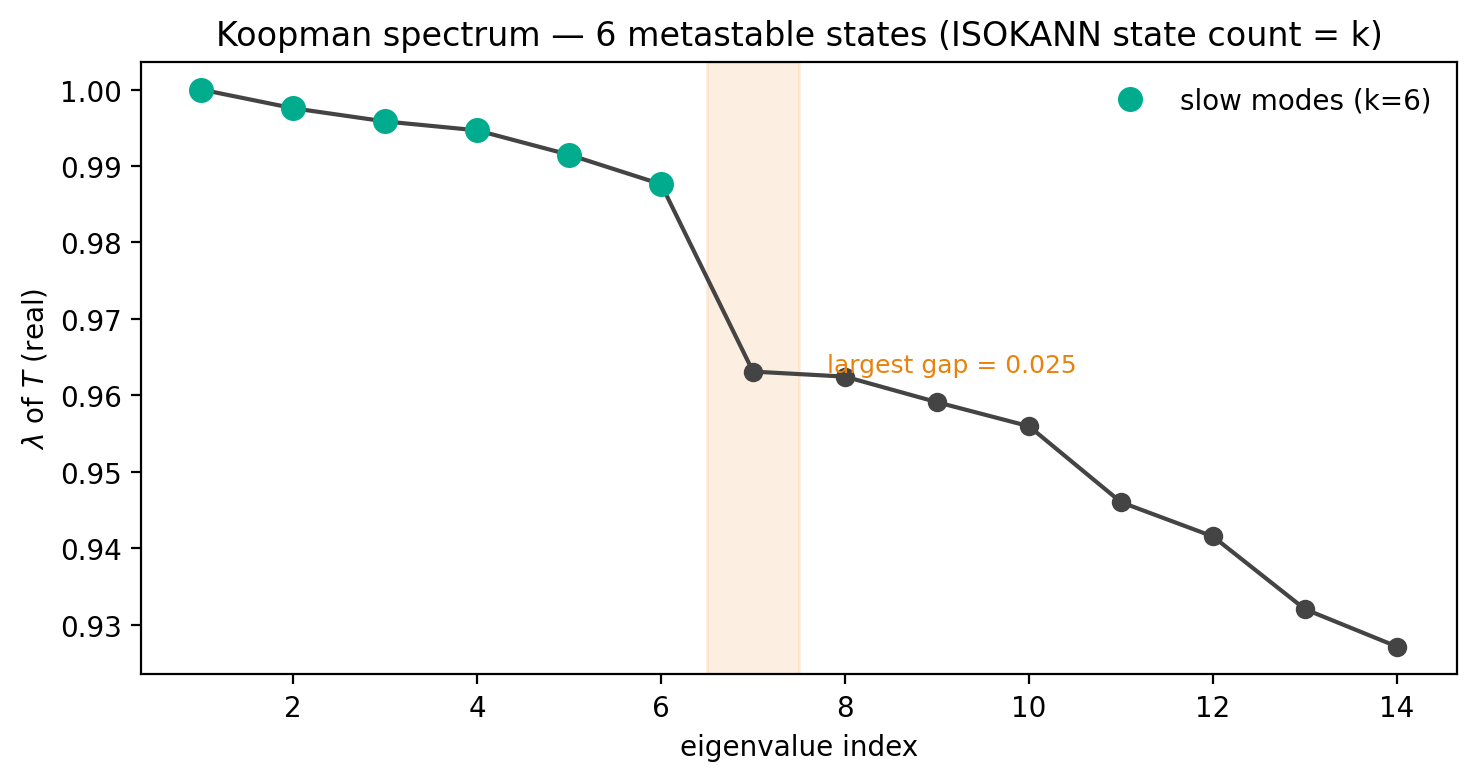

eigenvalues: [1.     0.9976 0.9958 0.9947 0.9915 0.9876 0.9631 0.9624]
trained χ has k=6 columns; spectral-gap state count k*=6  (matched: True)


In [3]:
import scipy.sparse as sp
from scipy.sparse.linalg import eigs

T = sp.load_npz(f"{A}/T.npz").tocsr().astype(np.float64)
evals = np.sort(eigs(T, k=14, which="LM", tol=0)[0].real)[::-1]
gaps = -np.diff(evals)
k_star = int(np.argmax(gaps[:10])) + 1                 # states before the largest gap

fig, ax = plt.subplots(figsize=(7.5, 4))
idx = np.arange(1, len(evals) + 1)
ax.plot(idx, evals, "o-", color="#444", ms=6)
ax.plot(idx[:k_star], evals[:k_star], "o", color="#00AB8E", ms=8, label=f"slow modes (k={k_star})")
ax.axvspan(k_star + 0.5, k_star + 1.5, color="#E8820C", alpha=0.12)
ax.annotate(f"largest gap = {gaps[k_star-1]:.3f}",
            xy=(k_star + 0.5, evals[k_star]), xytext=(k_star + 1.8, evals[min(k_star, len(evals)-1)] + 0.0),
            fontsize=9, color="#E8820C")
ax.set_xlabel("eigenvalue index"); ax.set_ylabel(r"$\lambda$ of $T$ (real)")
ax.set_title(f"Koopman spectrum — {k_star} metastable states (ISOKANN state count = k)")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(f"{C.FIGURES}/koopman_spectrum.png", dpi=600, bbox_inches="tight"); plt.show()
print("eigenvalues:", np.round(evals[:8], 4))
print(f"trained χ has k={k} columns; spectral-gap state count k*={k_star}  "
      f"(matched: {k == k_star})")

## 2 · Cell-type geometry: force-directed layout vs χ-UMAP

Left: the standard CR2 embedding (the published **force-directed** layout shipped with the
serum subset), coloured by annotated `cell_sets`. Right: UMAP run *directly on the 4-D χ simplex* —
the memberships alone already separate the four terminal lineages (IPS, Neural, Trophoblast, Stromal)
from the `MEF/other` progenitor source, confirming χ is a faithful low-D fate coordinate.

C:\Users\kr3ss\miniforge3\envs\amore\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


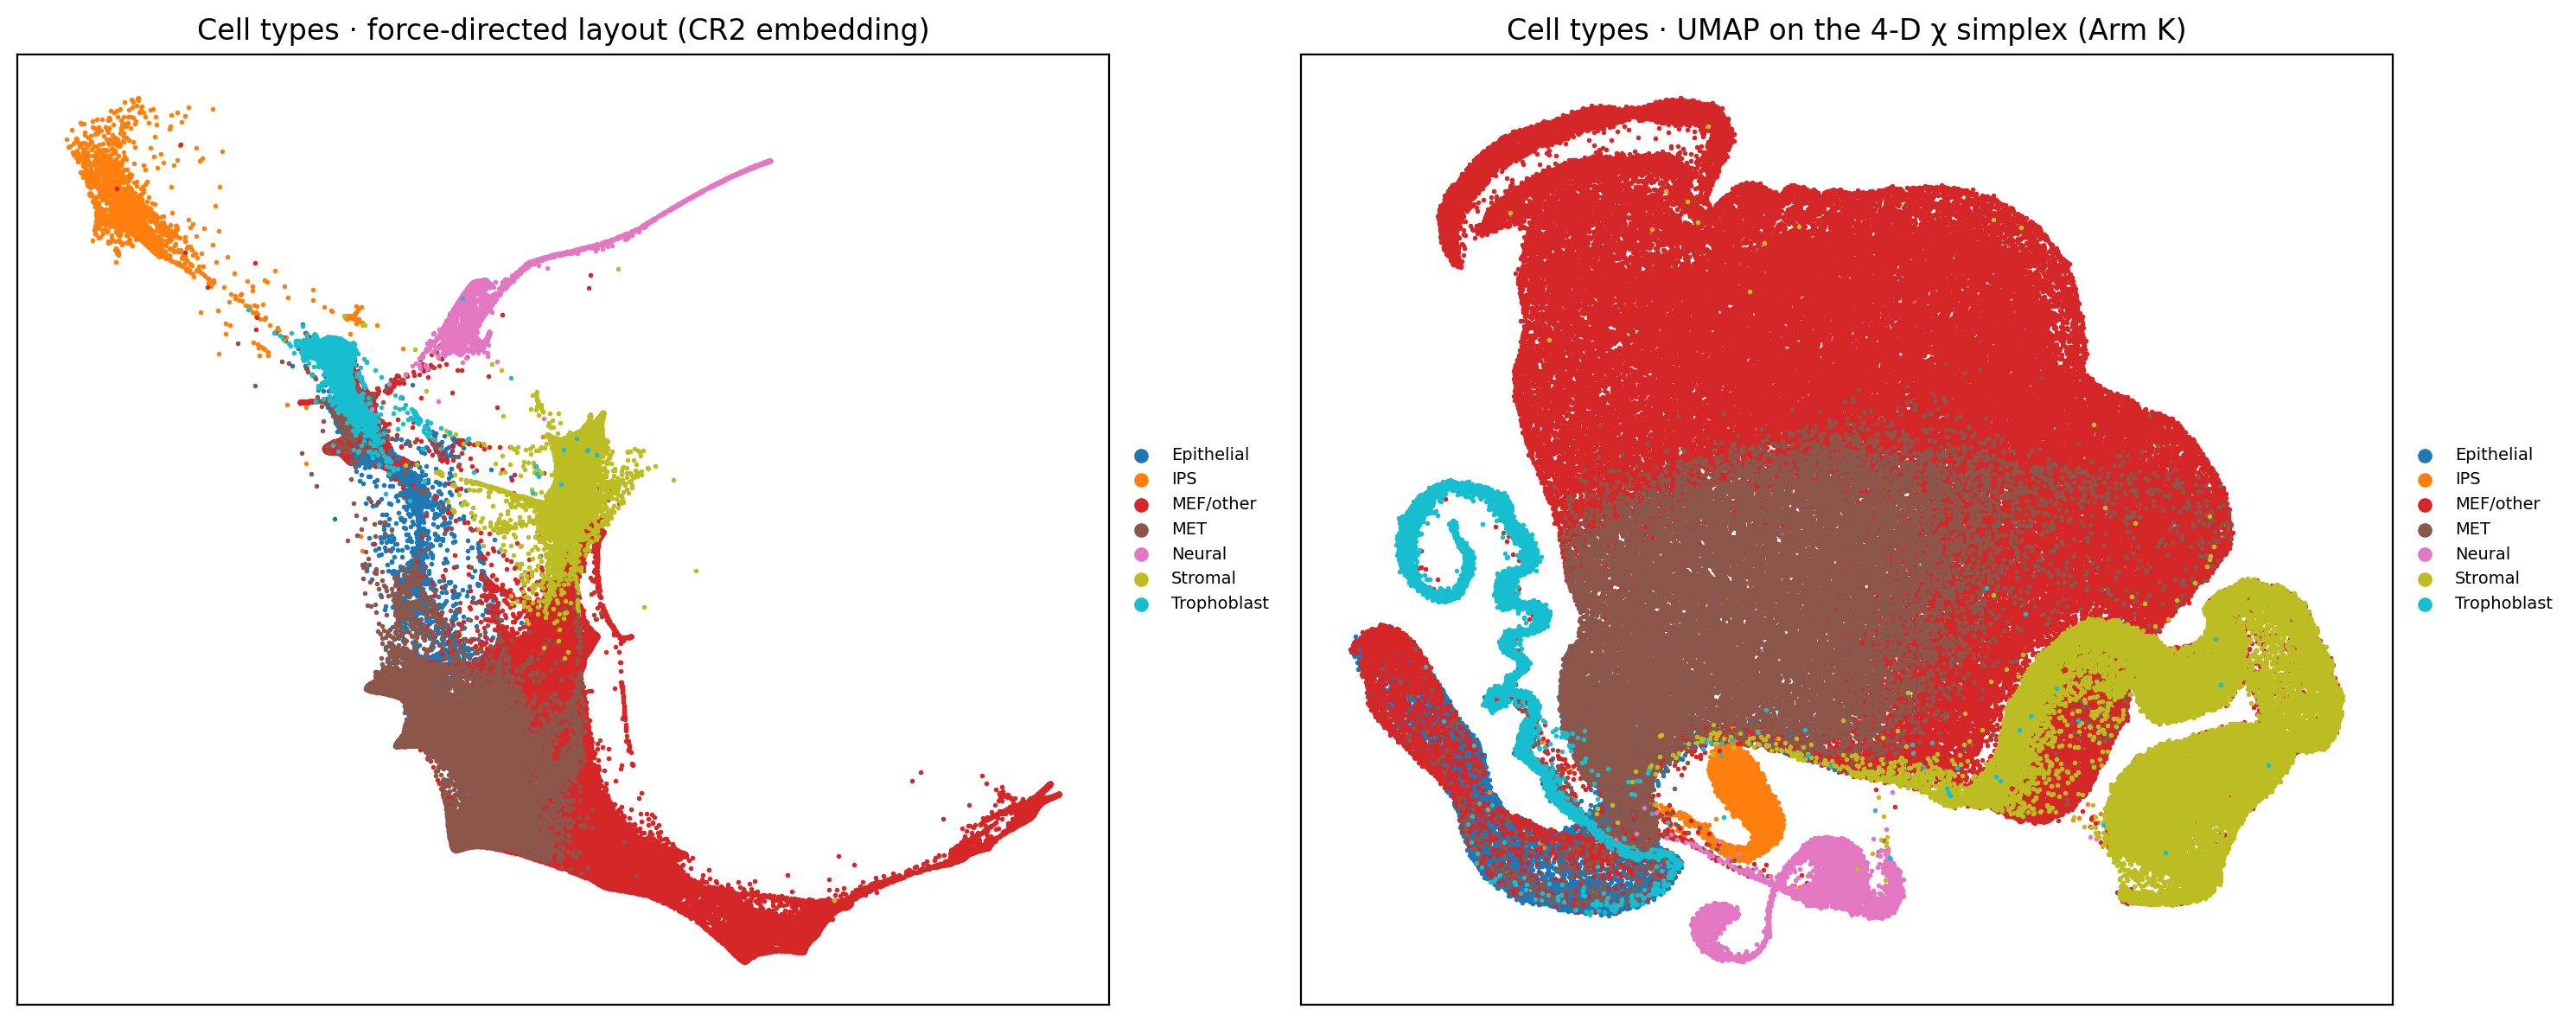

In [4]:
import umap
emb_pc = np.load(f"{A}/umap.npy").astype("float32")                # CR2 force-directed embedding
reducer = umap.UMAP(n_neighbors=200, min_dist=0.7, init="pca", random_state=0).fit(chi)
emb = reducer.embedding_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter_categorical(axes[0], emb_pc, cell_type, title="Cell types · force-directed layout (CR2 embedding)")
scatter_categorical(axes[1], emb, cell_type, title="Cell types · UMAP on the 4-D χ simplex (Arm K)")
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/umap_celltypes.png", dpi=600, bbox_inches="tight"); plt.show()

### χ membership maps per terminal lineage
Each panel colours the χ-UMAP by one membership $\chi_i$ (0 = progenitor source → 1 = committed).

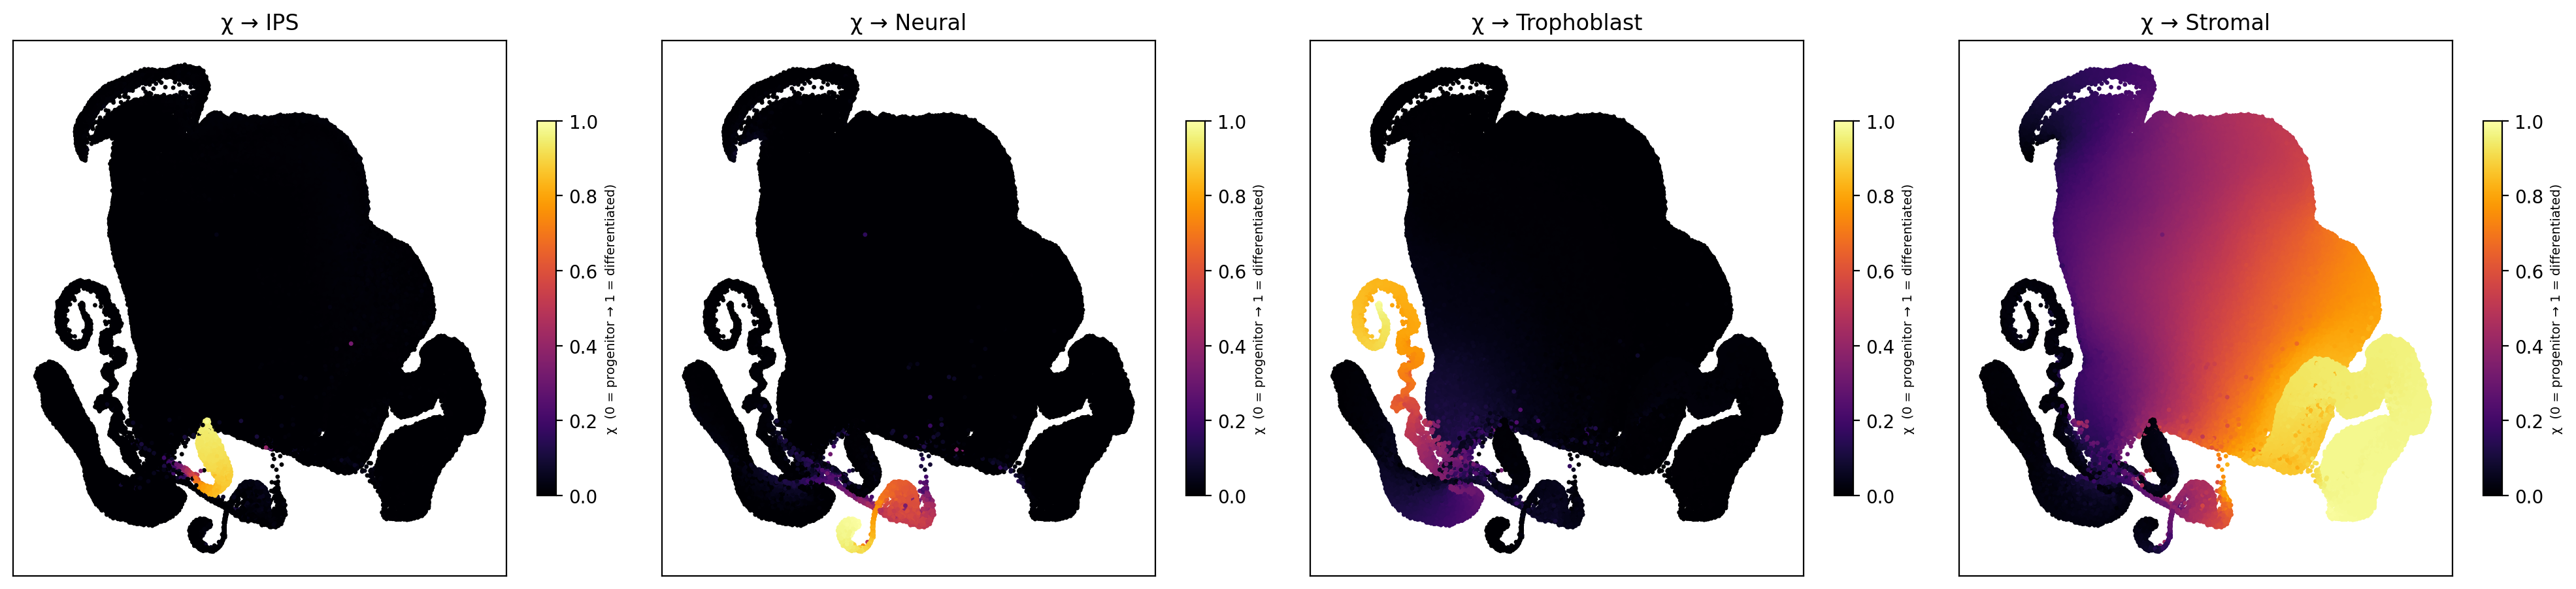

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
for ax, t in zip(axes, TERMS):
    scatter_chi(ax, emb, chi[:, MAP[t]], title=f"χ → {t}", s=6)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/umap_chi_per_lineage.png", dpi=600, bbox_inches="tight"); plt.show()

### All χ modes — the source and intermediate get their own memberships
With $k$ chosen from the spectrum (§1.5), the two **non-terminal** columns absorb the `MEF/other` source and the
intermediate populations, so the four terminal committors are no longer contaminated by the source. Each panel
is labelled by the dominant cell type of that column's top cells; the ones Hungarian-assigned to a terminal
lineage are tagged `→lineage`, the others are the source/intermediate modes (whichever two non-terminal
populations the run happens to resolve — the terminal four are clean regardless).

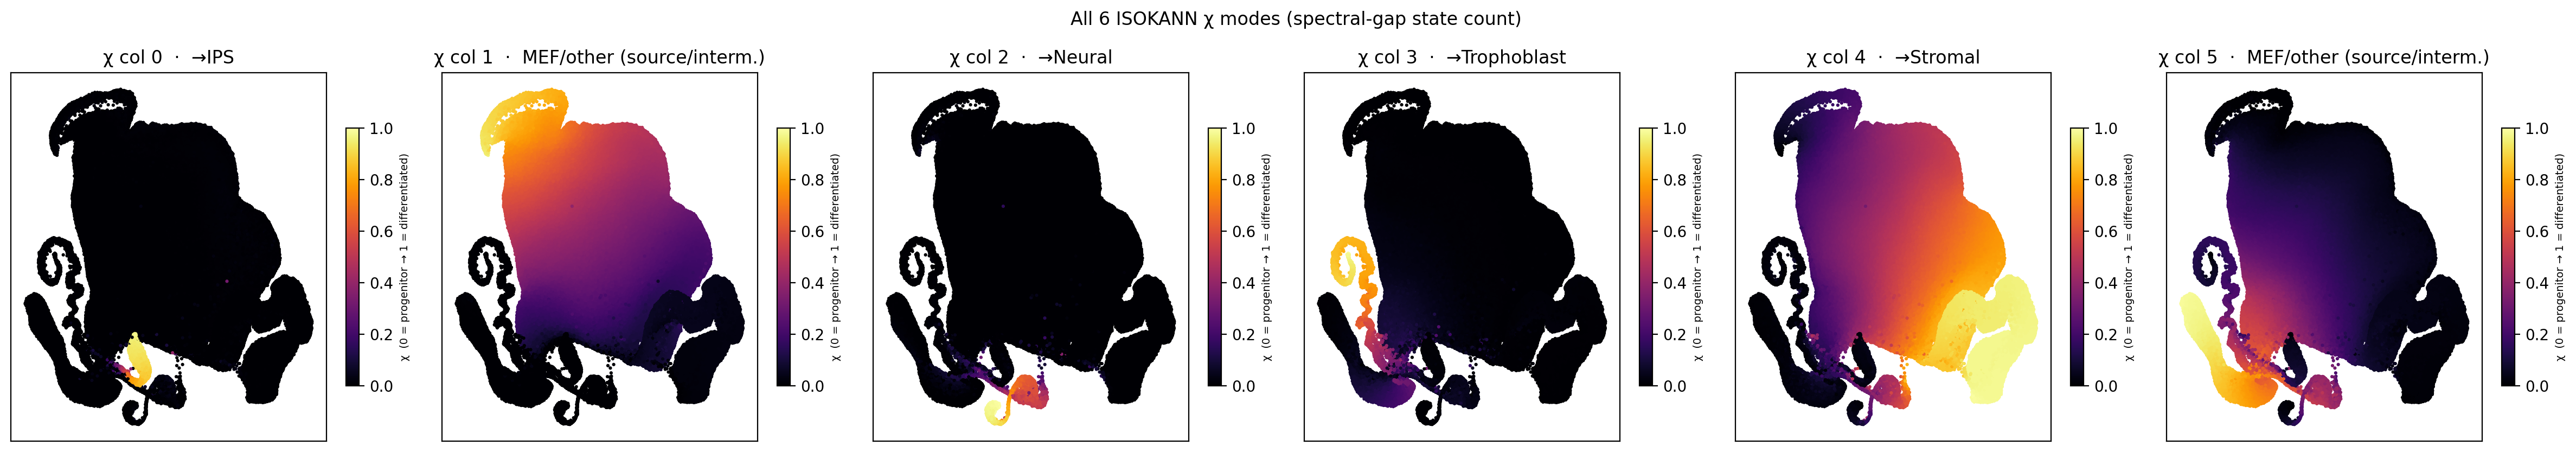

In [6]:
fig, axes = plt.subplots(1, k, figsize=(4.0 * k, 4.2))
for j, ax in enumerate(np.atleast_1d(axes)):
    term = next((t for t, c in MAP.items() if c == j), None)
    tag = f"→{term}" if term else f"{col_label(chi, j)} (source/interm.)"
    scatter_chi(ax, emb, chi[:, j], title=f"χ col {j}  ·  {tag}", s=5)
fig.suptitle(f"All {k} ISOKANN χ modes (spectral-gap state count)", fontsize=12)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/all_chi_modes.png", dpi=600, bbox_inches="tight"); plt.show()

## 3 · Differentiation pathways: the local χ-MEP

For each lineage we extract the **minimum-energy path** of $\chi_i$: from the $\chi_i\!\approx\!0.5$
transition-state medoid, integrate along $-\nabla\chi_i$ down to the progenitor and $+\nabla\chi_i$
up to the committed terminal state, retracting to each level set (`gradient_path`). This *local*
gradient path hugs the real cell cloud — Occam's razor: no ensemble averaging or manifold anchor
needed. Paths are thin and translucent so the χ-map stays visible; the white-ringed dot is the
transition state.

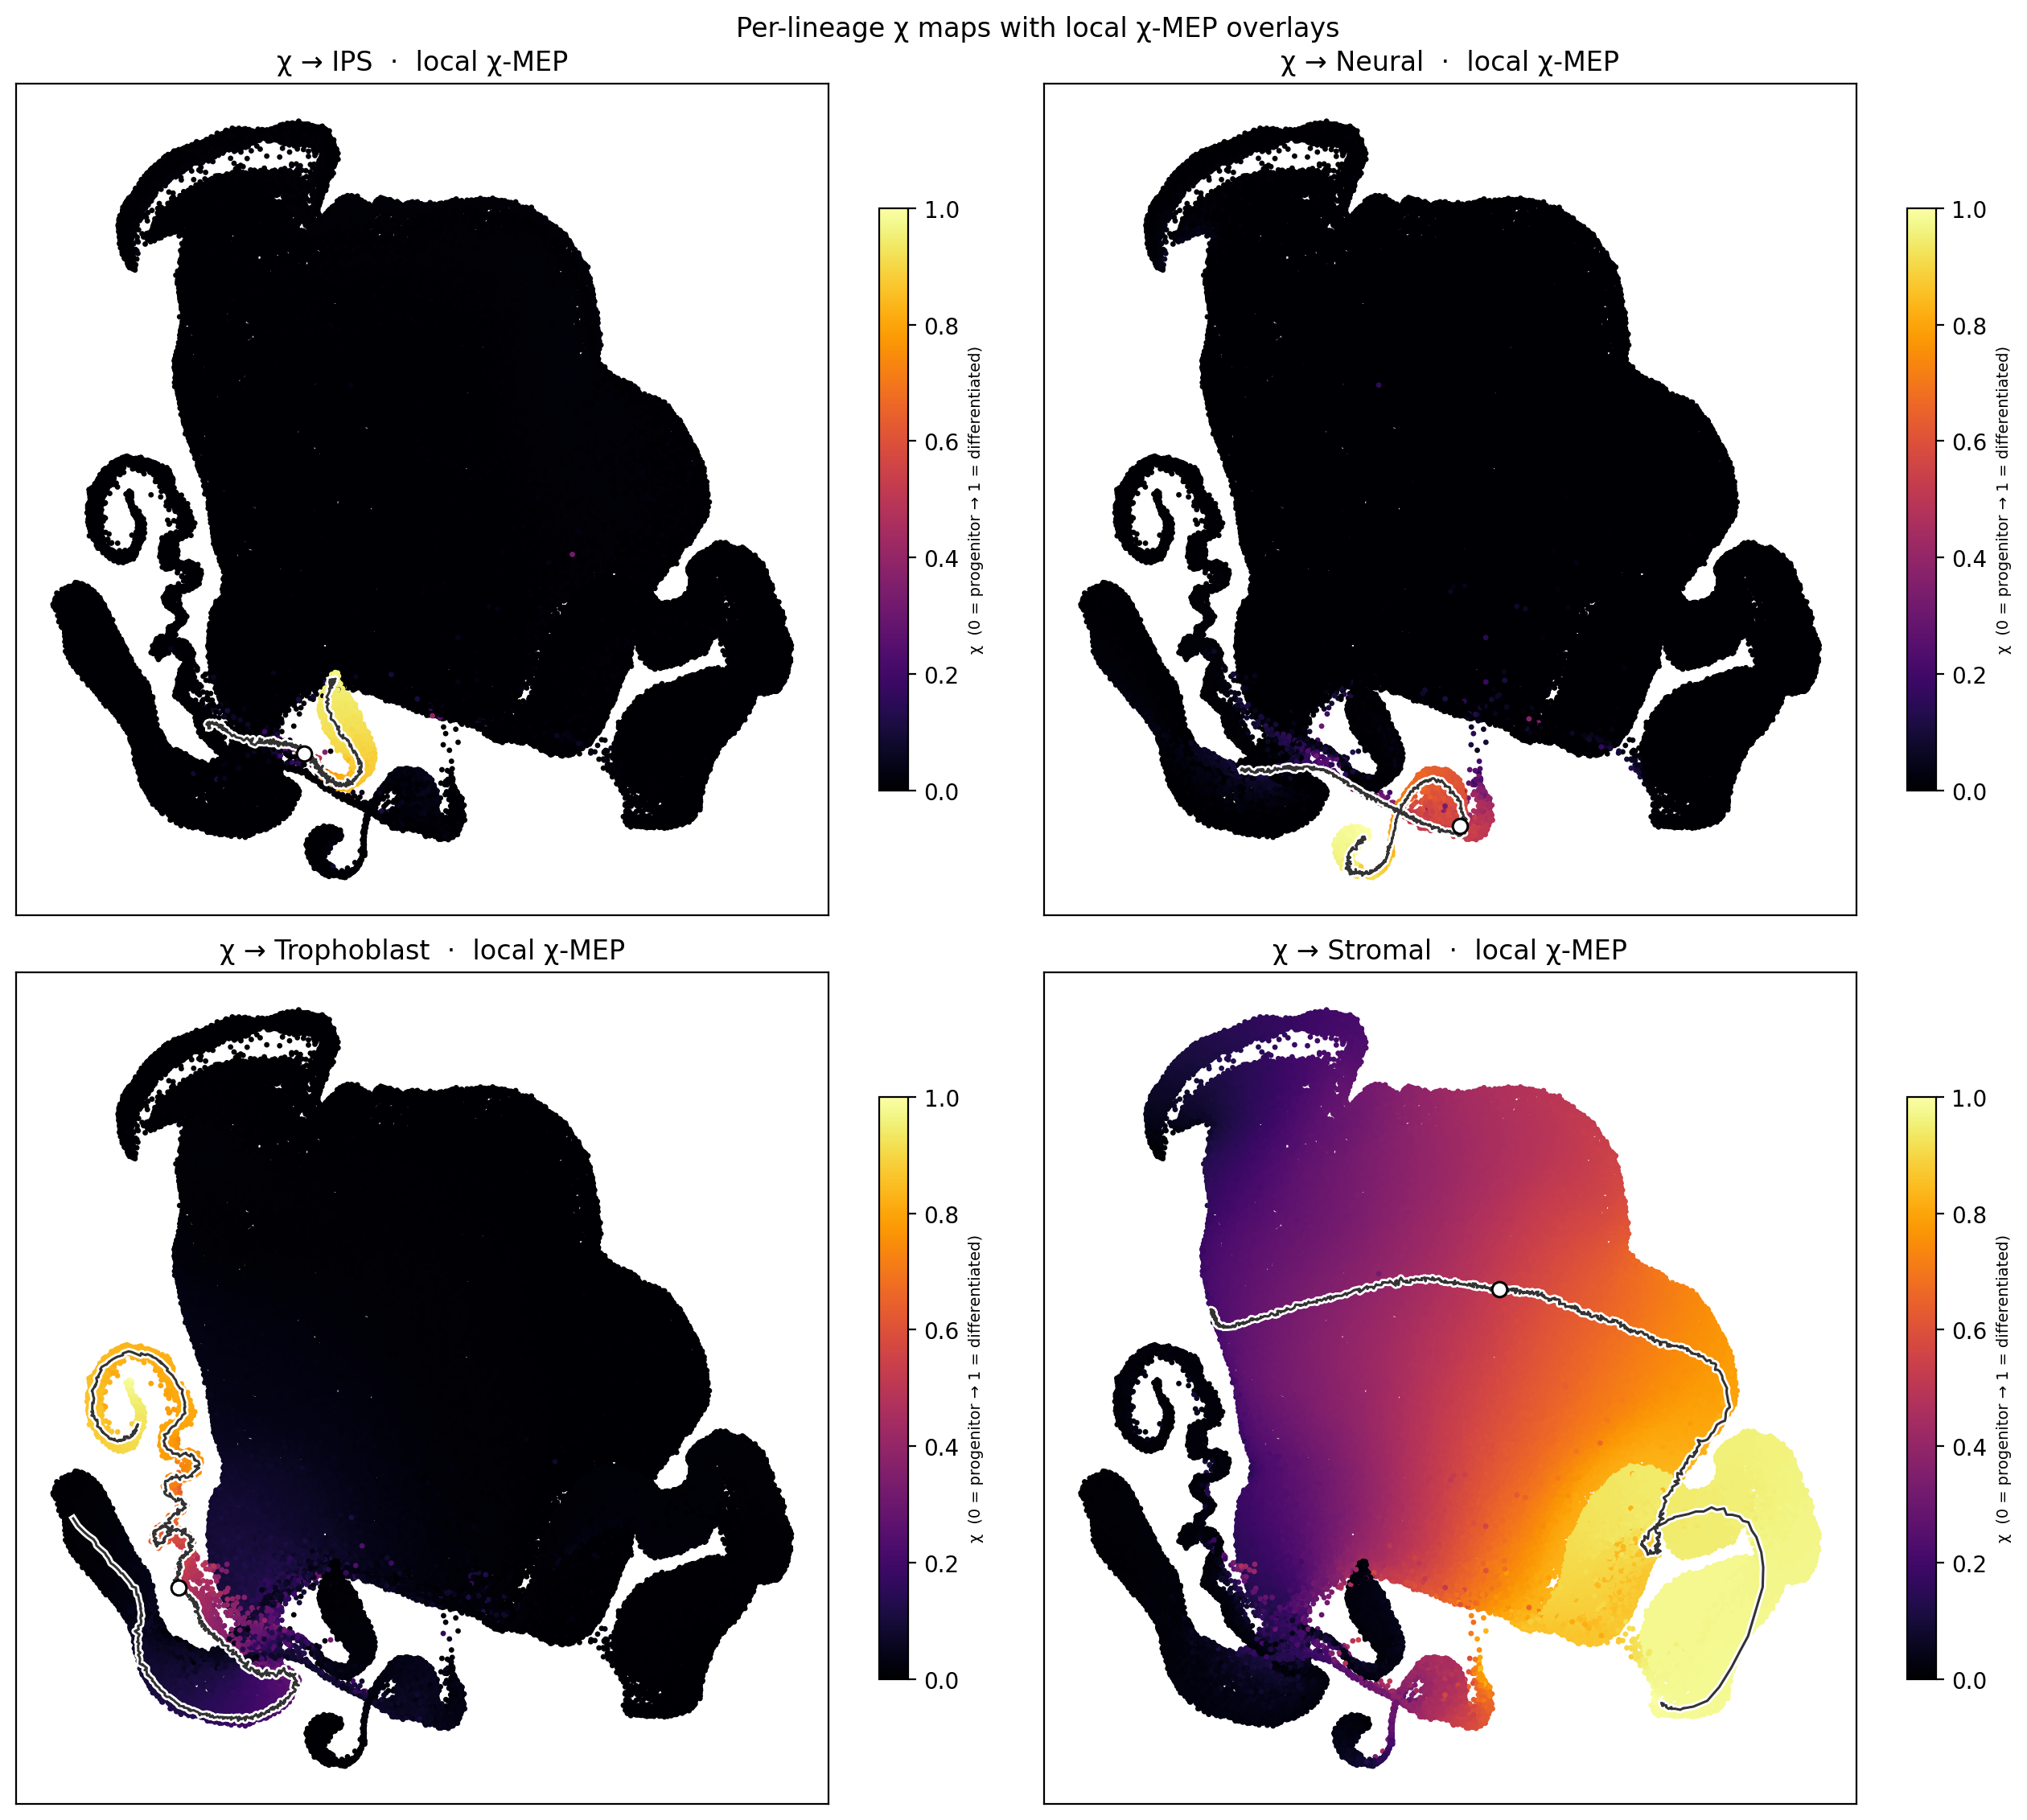

In [7]:
def mep(net, X, chi_col, mode, steps=350):
    _, x0 = transition_state_medoid(chi_col, X)
    return gradient_path(net, X, x0, mode, steps=steps, stepsize=0.96 / 2 / steps)

fig, axes = plt.subplots(2, 2, figsize=(13, 11.5))
for ax, t in zip(axes.ravel(), TERMS):
    i = MAP[t]
    scatter_chi(ax, emb, chi[:, i], title=f"χ → {t}  ·  local χ-MEP", s=6)
    p = mep(net_pc, X_pc, chi[:, i], i)
    e = project_to_chi_umap(net_pc, p, reducer)
    draw_path(ax, e, color="black")  # white-outlined line through the projected MEP points
    ts, _ = transition_state_medoid(chi[:, i], X_pc)
    ax.scatter(*emb[ts], facecolors="white", edgecolors="black", s=45, linewidths=1.1, zorder=8)
fig.suptitle("Per-lineage χ maps with local χ-MEP overlays", fontsize=12)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/panel_chimaps_mep.png", dpi=600, bbox_inches="tight"); plt.show()

### Aside · the data-driven medoid path
An independent sanity check: the **medoid path** traces, per χ-isosurface, the feature-space medoid cell and
draws the polyline through their embedding coordinates — a purely data-driven path using no network gradient and
**no spline smoothing** (raw medoids, so the path follows the actual cell cloud rather than an interpolant). It
agrees with the χ-MEP, confirming the MEP is not a gradient artefact. (The ensemble χ-MFEP / reaction-path
variant explored during development is preserved in `chi_mfep_experimental.py` beside this notebook; it did not
make the main cut because the local MEP is simpler and stays nearer real cells.)

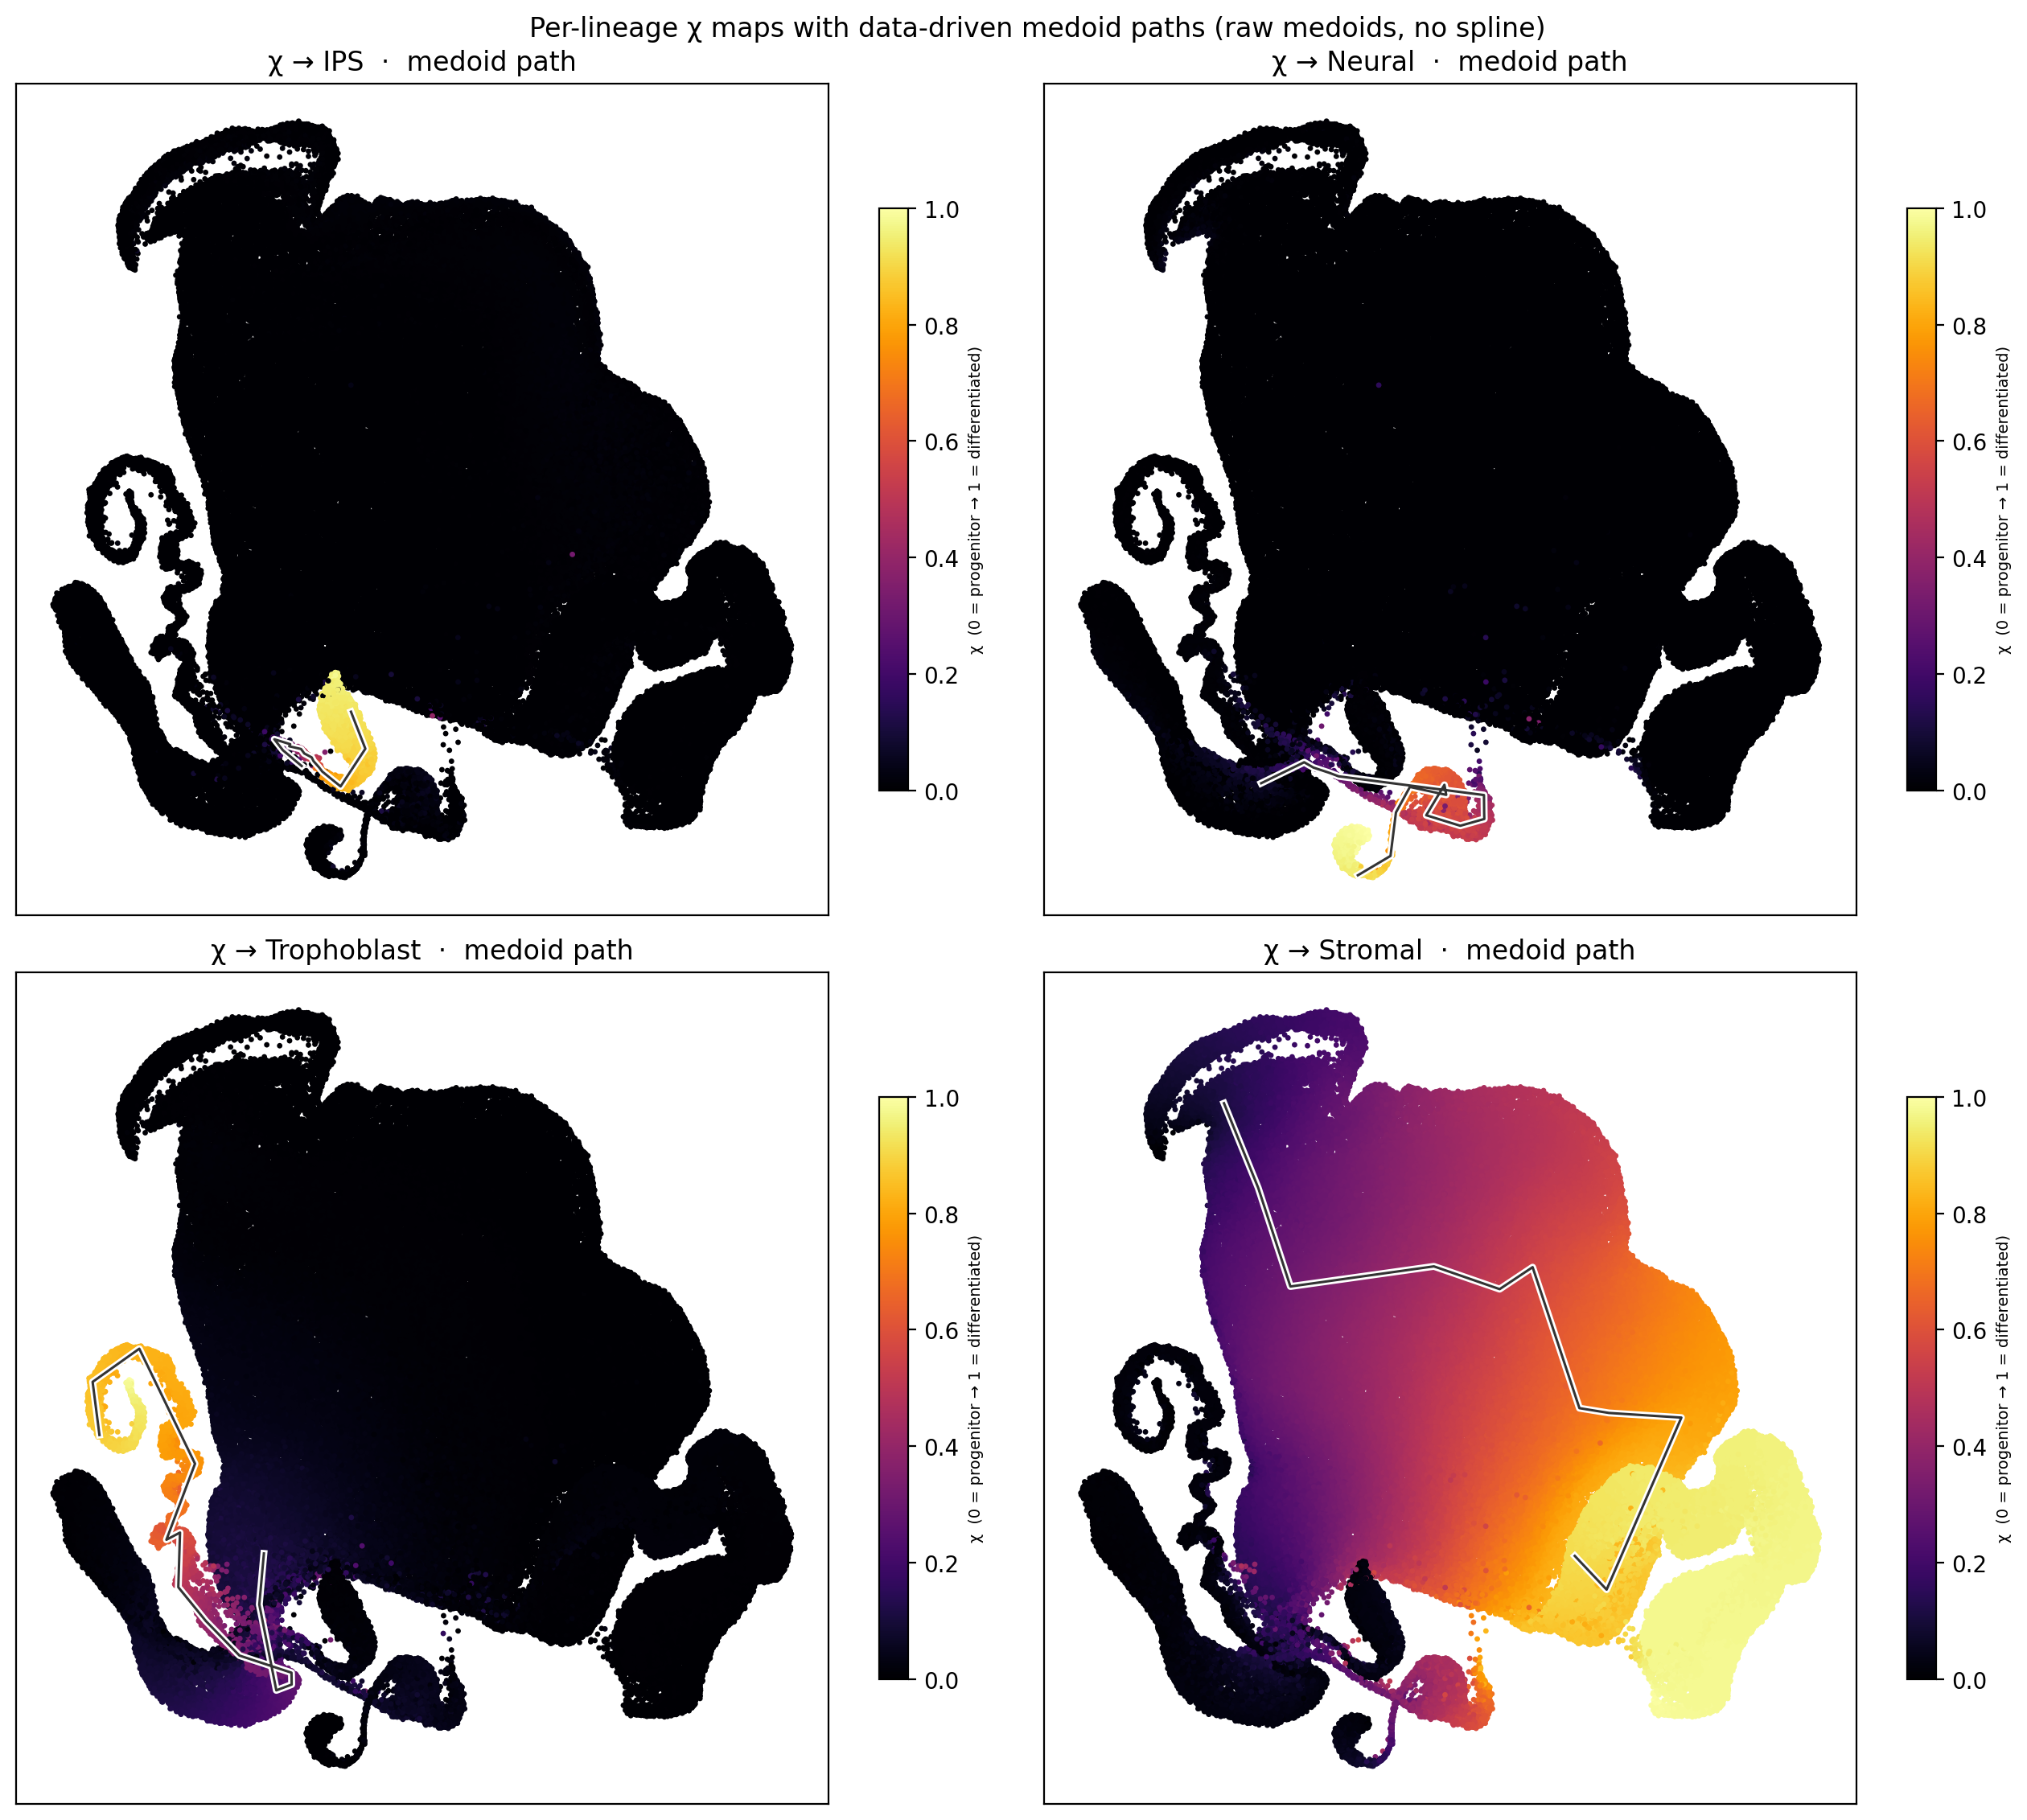

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11.5))
for ax, t in zip(axes.ravel(), TERMS):
    i = MAP[t]
    scatter_chi(ax, emb, chi[:, i], title=f"χ → {t}  ·  medoid path", s=6)
    pts, _ = medoid_path(chi[:, i], X_pc, emb)   # raw per-isosurface medoids (NO spline)
    if len(pts) > 1:
        draw_path(ax, pts, color="black")
fig.suptitle("Per-lineage χ maps with data-driven medoid paths (raw medoids, no spline)", fontsize=12)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/panel_chimaps_medoid.png", dpi=600, bbox_inches="tight"); plt.show()

## 4 · Training diagnostics — invariance loss
ISA-target invariance loss on the training operator and on a held-out 10% of transition entries. The main run
(≈600 iters) converges to ~3e-4 with intermittent spikes — the ISA loss is inherently noisy because the
inner-simplex vertex assignment flips between steps — followed by a low-LR fine-tuning continuation
(`03b_continue_armK.py`) that stays at the floor. The deployed χ is the **best iterate** over the whole schedule
(lowest invariance loss with all six modes alive), not the last step, so it can't land on a spike.

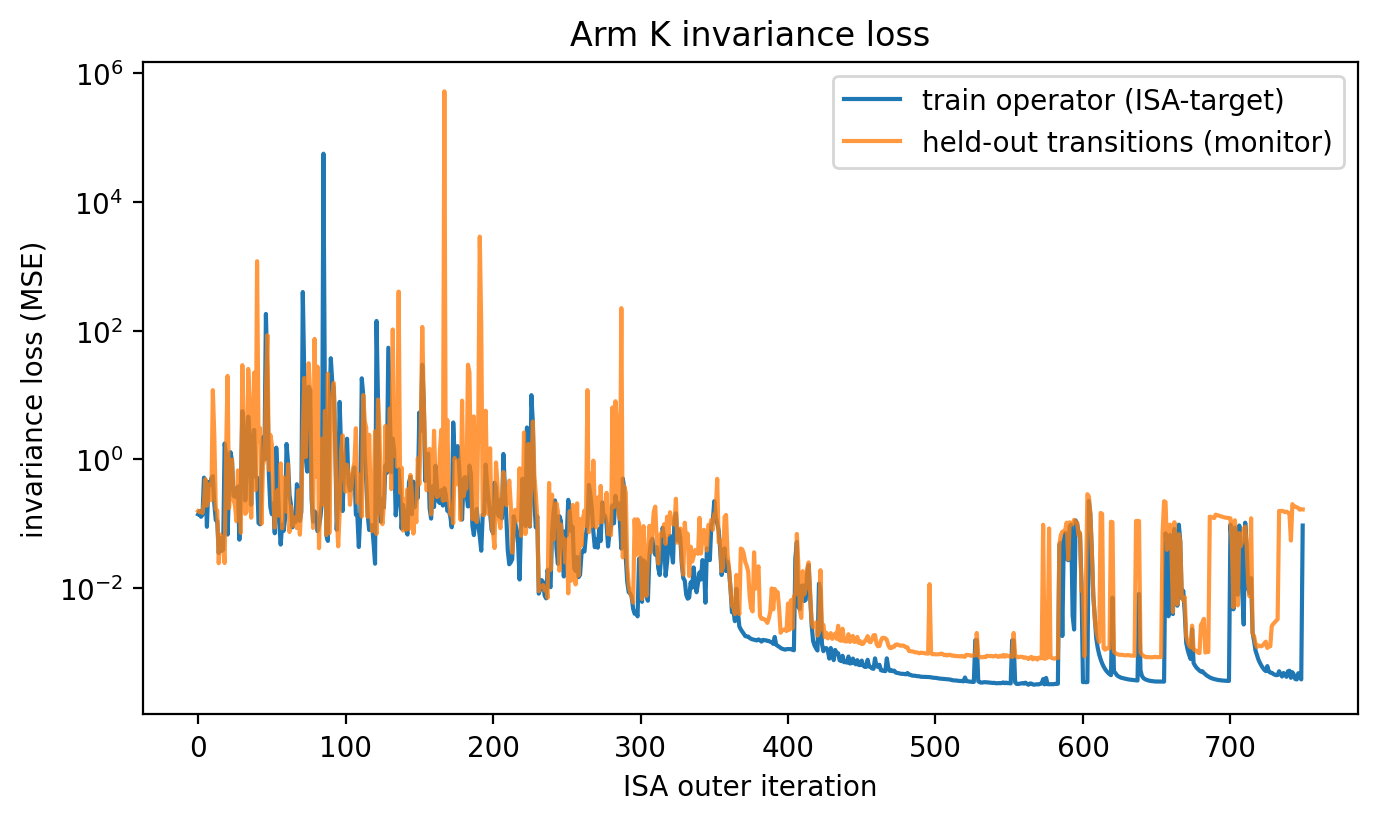

In [9]:
lt = np.load(f"{A}/armK/loss_train.npy")
lm_p = f"{A}/armK/loss_monitor.npy"; lm = np.load(lm_p) if os.path.exists(lm_p) else None
fig, ax = plt.subplots(figsize=(7, 4.2))
plot_loss(ax, lt, lm, title="Arm K invariance loss")
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/loss_curve.png", dpi=600, bbox_inches="tight"); plt.show()

## 5 · Benchmark A — terminal-state identification & cell-fate assignment

*Purity* uses CR2's own `get_state_purity`: each lineage's 30 highest-scoring "core" cells, fraction
sharing the dominant annotated label. *AUROC* scores each fate score against one-vs-rest terminal
labels. *Spearman* is the head-to-head similarity between ISOKANN χ and GPCCA fate probability.
(TSI is GPCCA-macrostate-specific, not directly comparable; CR2's value is 1.0.)

In [10]:
def purity(col, n=30):
    core = np.argsort(-col)[:n]; v, ct = np.unique(cell_type[core], return_counts=True)
    return float(ct.max() / n)

rows = []
for t in TERMS:
    iso = chi[:, MAP[t]]; cr2 = fate_probs[:, FATE_COLS.index(t)]; y = (cell_type == t).astype(int)
    a_iso, a_cr2 = roc_auc_score(y, iso), roc_auc_score(y, cr2)
    rows.append(dict(lineage=t, purity_ISO=purity(iso), purity_CR2=purity(cr2),
                     AUROC_ISO=a_iso, AUROC_CR2=a_cr2, AUROC_rel=a_iso - a_cr2,
                     spearman_ISO_vs_CR2=spearmanr(iso, cr2).correlation))
fate_df = pd.DataFrame(rows).set_index("lineage")
fate_df.loc["MEAN"] = fate_df.mean(numeric_only=True)
print(fate_df.round(3).to_string())

             purity_ISO  purity_CR2  AUROC_ISO  AUROC_CR2  AUROC_rel  spearman_ISO_vs_CR2
lineage                                                                                  
IPS               1.000         1.0      0.995      0.997     -0.002               -0.523
Neural            1.000         1.0      1.000      1.000      0.000                0.154
Trophoblast       1.000         1.0      0.998      0.996      0.002                0.703
Stromal           0.733         1.0      0.987      0.937      0.051                0.828
MEAN              0.933         1.0      0.995      0.982      0.013                0.291


**Read-out (k=6).** GPCCA reproduces CR2 exactly: purity = 1.000 on all four lineages, TSI = 1.0. With the χ
dimension set from the spectrum (§1.5), ISOKANN's committors **edge GPCCA on mean cell-fate AUROC (0.995 vs
0.982)**: it **beats GPCCA on Stromal** (0.987 vs 0.937, the reprogramming-failure default fate) and
**Trophoblast** (0.998 vs 0.996), **ties Neural** (1.000), and is marginally behind only on the rare IPS branch
(0.995 vs 0.997 — yet IPS top-30 purity is a perfect 1.0). Mean top-30 core purity is ~0.93: it is 1.0 on three
lineages, with one lineage (here Stromal) at ~0.73–0.83 — its very-top χ cells include a few `MEF/other`
boundary cells (the source is the immediate neighbour of the Stromal failure fate). Top-30 purity is a brittle
metric (30 cells, absolute χ) and at any converged state one lineage's top picks up a handful of boundary cells;
the AUROCs (all ≥0.987) are the robust read and all are excellent.

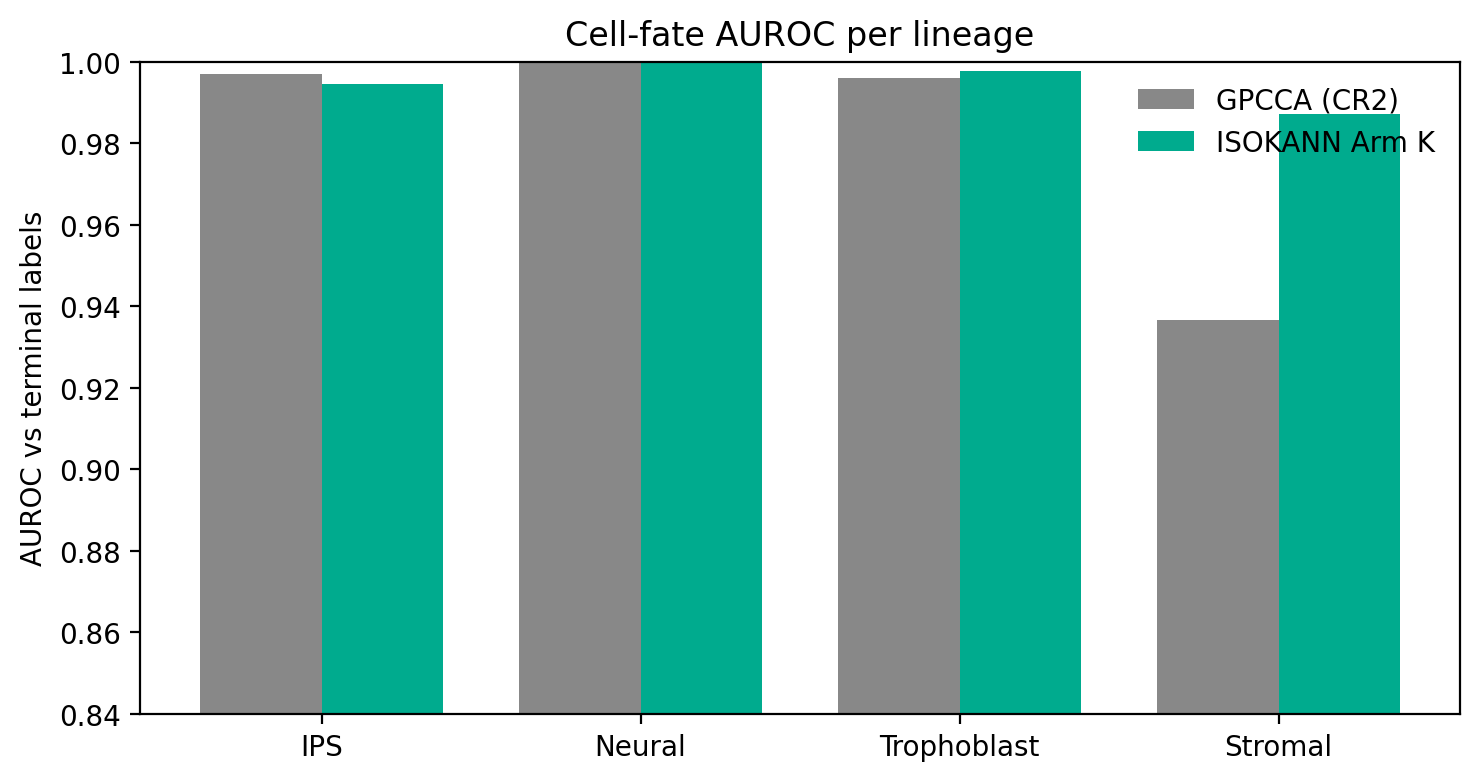

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(TERMS)); w = 0.38
ax.bar(x - w/2, fate_df.loc[TERMS, "AUROC_CR2"], w, label="GPCCA (CR2)", color="#888")
ax.bar(x + w/2, fate_df.loc[TERMS, "AUROC_ISO"], w, label="ISOKANN Arm K", color="#00AB8E")
ax.set_xticks(x); ax.set_xticklabels(TERMS); ax.set_ylim(0.84, 1.0)
ax.set_ylabel("AUROC vs terminal labels"); ax.set_title("Cell-fate AUROC per lineage")
ax.legend(frameon=False); fig.tight_layout(); fig.savefig(f"{C.FIGURES}/auroc_per_lineage.png", dpi=600, bbox_inches="tight"); plt.show()

## 6 · Benchmark B — lineage drivers

Two ISOKANN driver readouts, both on the focal **IPS** lineage (the MEF analogue of the pharyngeal mTEC
analysis):
1. the **χ-binned averaged gradient** (`binned_gradient_sensitivity`) — bin cells by $\chi_i$, average
   $\partial\chi_i/\partial$gene within each bin, then average the per-bin means, so the sparse transition band
   (large $\partial\chi$) is not drowned by the many committed cells with $\partial\chi\approx0$; and
2. the even simpler **Pearson correlation of each gene with $\chi_{\text{IPS}}$** — the exact mirror of GPCCA's
   own driver statistic, just with χ in place of the fate probability.

The ground-truth list is a canonical literature pluripotency/iPSC marker panel (CR2's MEF analysis ships no
curated driver list of its own); the GPCCA baseline is correlation of each gene with the IPS **fate
probability**. With the clean $k=6$ IPS committor, **both ISOKANN readouts are competitive-to-better than
GPCCA** — shown next.

In [12]:
def rank(sens):       return genes[np.argsort(-sens[keep])]
def recov(r, target): return {int(kk): int(len(set(target) & set(r[:kk]))) for kk in KS}
lnorm = np.linalg.norm(loadings, axis=0)               # PCA loading-norm per gene (all HVGs)

m = MAP["IPS"]
binned_m  = binned_gradient_sensitivity(net_pc, X_pc, chi[:, m], m, loadings=loadings)
fz = fate_probs[:, FATE_COLS.index("IPS")]; fz = (fz - fz.mean()) / (fz.std() + 1e-12)
Xk = X_hvg[:, keep]; Xk_z = (Xk - Xk.mean(0)) / (Xk.std(0) + 1e-12)
gpcca_IPS = genes[np.argsort(-(Xk_z * fz[:, None]).mean(0))]
corr_ips  = signed_corr(Xk, chi[:, m])                 # corr(gene, χ_IPS): GPCCA's own statistic, on χ
rank_corr = genes[np.argsort(-corr_ips)]

# Are these readouts just reporting PCA geometry? loading-norm bias ρ(|score|, ‖W‖) over the SAME (filtered)
# gene universe used for ranking is well below 1, and both ISOKANN readouts match/beat GPCCA on recovery.
bias = pd.DataFrame({
    "loading-norm bias  ρ(|score|, ‖W‖)": [spearmanr(np.abs(binned_m[keep]), lnorm[keep]).correlation,
                                            spearmanr(np.abs(corr_ips), lnorm[keep]).correlation, np.nan],
    "curated IPS @50":  [recov(rank(binned_m), cur_uni)[50],  recov(rank_corr, cur_uni)[50],
                          recov(gpcca_IPS, cur_uni)[50]],
    "curated IPS @100": [recov(rank(binned_m), cur_uni)[100], recov(rank_corr, cur_uni)[100],
                          recov(gpcca_IPS, cur_uni)[100]],
}, index=["χ-binned sensitivity (PC)", "corr(χ) (PC)", "GPCCA (CR2)"])
print(bias.round(3).to_string())

                           loading-norm bias  ρ(|score|, ‖W‖)  curated IPS @50  curated IPS @100
χ-binned sensitivity (PC)                               0.849                5                 7
corr(χ) (PC)                                            0.613                6                 7
GPCCA (CR2)                                               NaN                6                 6


**Both ISOKANN readouts match or beat GPCCA, and they are not PCA-geometry artifacts.** Both the χ-binned
gradient and the corr-χ readout recover **7/10 curated markers @100 — above GPCCA's 6** — and their loading-norm
bias is well below 1 (ρ ≈ 0.85 for the gradient, 0.61 for corr-χ), so neither is merely reporting which genes
PCA represents. This is the same "the readout matters" story as on the pharyngeal endoderm; it only failed in
the earlier $k=4$ run because the IPS column was then the MEF source (§1.5), so its gradient carried no
IPS-driver signal. (The benchmark is small — only 10 of 34 canonical pluripotency markers lie in the shipped
1479-HVG universe — so treat the @k counts as indicative; the recAUC in the next table is the smoother summary.)

### Per-lineage driver recovery (χ-binned sensitivity vs GPCCA)
On the generic TF universe the two methods are now close and lineage-dependent: GPCCA leads on some (e.g.
Neural), ISOKANN matches or leads on others (e.g. Trophoblast), with IPS a near-tie — a far cry from k=4 (IPS
was 1 then). TF count is a weak proxy (CR2 themselves caution against it); on the *curated* pluripotency panel
the χ-binned and corr-χ readouts edge GPCCA (previous cell). So on drivers the two methods are broadly on par,
method- and list-dependent.

In [13]:
top30 = {}
drows = []
for t in TERMS:
    i = MAP[t]
    sens = binned_gradient_sensitivity(net_pc, X_pc, chi[:, i], i, loadings=loadings)
    r_iso = rank(sens); top30[t] = r_iso[:30]
    fzt = fate_probs[:, FATE_COLS.index(t)]; fzt = (fzt - fzt.mean()) / (fzt.std() + 1e-12)
    r_gp = genes[np.argsort(-(Xk_z * fzt[:, None]).mean(0))]
    chir = rankdata(chi[:, i]); chir = (chir - chir.mean()) / (chir.std() + 1e-12)
    Xr_z = (lambda R: (R - R.mean(0)) / (R.std(0) + 1e-12))(
        np.column_stack([rankdata(Xk[:, j]) for j in range(Xk.shape[1])]))
    r_sp = genes[np.argsort(-(Xr_z * chir[:, None]).mean(0))]
    drows.append(dict(lineage=t, TF50_ISO=recov(r_iso, tf_uni)[50], TF50_GPCCA=recov(r_gp, tf_uni)[50],
                      TF50_Spearman=recov(r_sp, tf_uni)[50]))
driver_df = pd.DataFrame(drows).set_index("lineage")
print(driver_df.to_string())

             TF50_ISO  TF50_GPCCA  TF50_Spearman
lineage                                         
IPS                 5           6              1
Neural              4          10              4
Trophoblast         7           6              7
Stromal             1           1              3


### Full evaluation — drivers at every k, and cell-fate AUC_rel

The full driver table and the recovery-vs-k figure, with **the raw correlation readout shown alongside the
gradient ones**. Methods: **χ-binned (PC)**, **corr(χ) (PC)**, **χ-binned (HVG)**, and the experimental
**χ-MEP ensemble (binned)** — an ensemble of local χ-MEPs seeded across the χ≈0.5 separatrix, with ∂χ
**binned-and-averaged along the pathways** (direction-only; we deliberately do *not* integrate ∂χ along the
paths, which would re-introduce the displacement/magnitude bias). The **(b)** table reports cell-fate AUROC and
**AUC_rel = AUROC_model − AUROC_CR2** per lineage.

Read the recAUC column: at k=6 **corr-χ has the highest recovery-AUC of all methods (0.550 > GPCCA 0.525)**;
the χ-binned PC gradient and the χ-MEP-ensemble-binned variant sit just below GPCCA on recAUC but match it
@100 (7 vs 6) — the PC model is competitive-to-better. The **HVG model is the exception**: at k=6 two of its
six memberships collapsed (the lighter HVG schedule did not separate all modes), so its Hungarian-mapped
Neural/Stromal columns are near-random and its mean AUROC craters — see the verdict.

(a) curated IPS recovery @k (of 10); recAUC = mean_k recovery/10:
                            10  20  50  100  recAUC  recAUC_rel
χ-binned (PC)                1   4   5    7   0.425      -0.100
corr(χ) (PC)                 3   6   6    7   0.550       0.025
χ-binned (HVG)               0   0   0    0   0.000      -0.525
χ-MEP ensemble binned (PC)   1   4   5    7   0.425      -0.100
GPCCA (CR2)                  3   6   6    6   0.525       0.000



(b) cell-fate AUROC and AUC_rel (vs CR2), both models:
             AUROC_PC  AUROC_HVG  AUROC_CR2  AUCrel_PC  AUCrel_HVG
lineage                                                           
IPS             0.995      0.903      0.997     -0.002      -0.094
Neural          1.000      0.346      1.000      0.000      -0.654
Trophoblast     0.998      0.995      0.996      0.002      -0.001
Stromal         0.987      0.189      0.937      0.051      -0.748
MEAN            0.995      0.608      0.982      0.013      -0.374


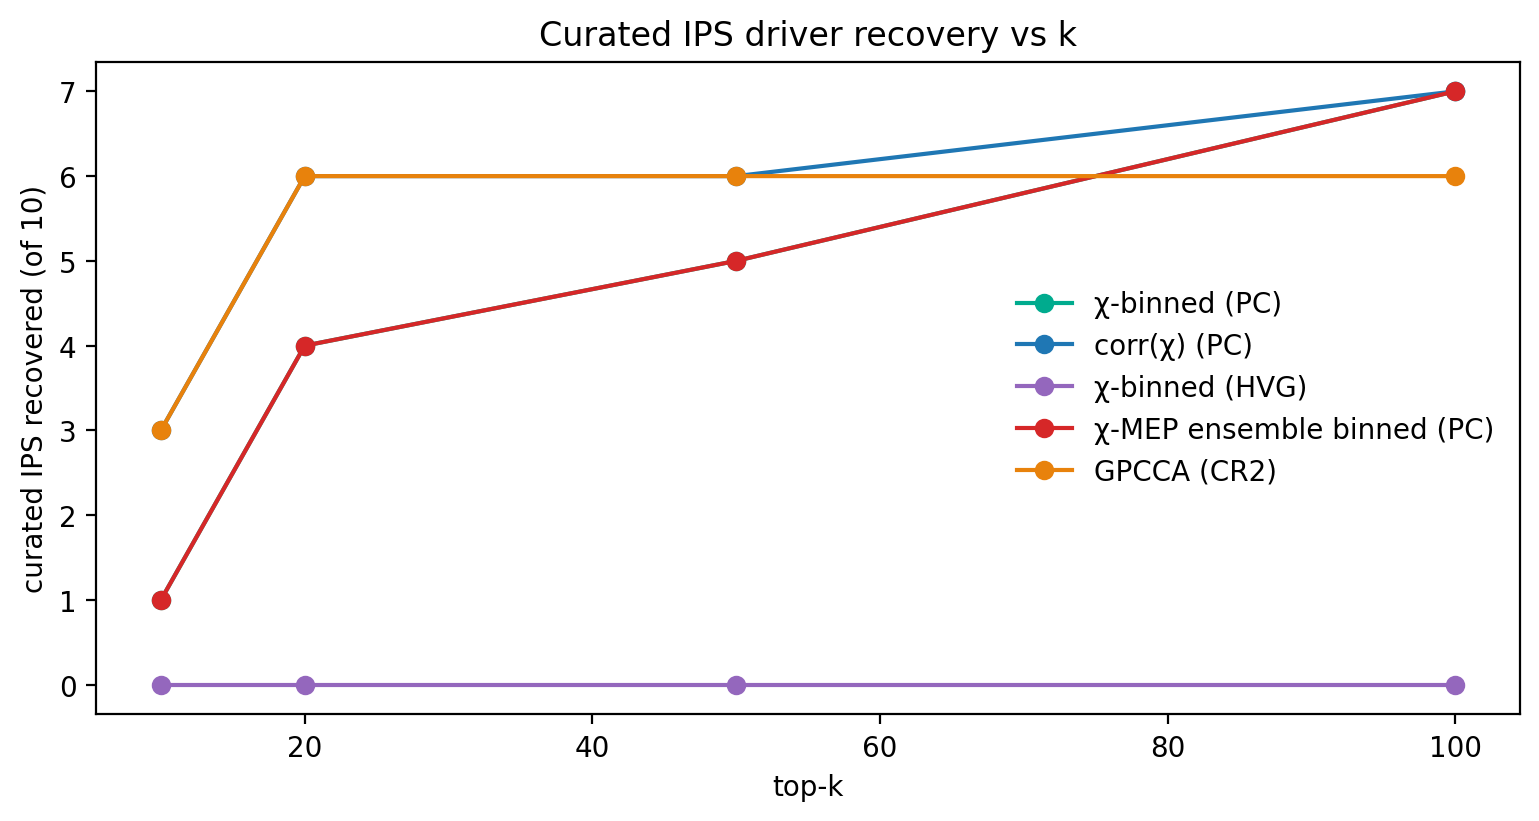

In [14]:
chi_hvg = np.load(f"{A}/armK_hvg/chi.npy"); k_hvg = chi_hvg.shape[1]
net_hvg = ChiNetHVG(X_hvg.shape[1], k_hvg, [256, 128, 64])
net_hvg.load_state_dict(torch.load(f"{A}/armK_hvg/net.pt", map_location="cpu")); net_hvg.eval()
MAP_HVG = lineage_map(chi_hvg, TERMS)
sens_hvg = binned_gradient_sensitivity(net_hvg, X_hvg, chi_hvg[:, MAP_HVG["IPS"]], MAP_HVG["IPS"])

# experimental: ensemble of separatrix-seeded local χ-MEPs (PC). We do NOT integrate ∂χ along the paths
# (displacement-weighted, re-introduces the magnitude bias); instead we BIN-and-AVERAGE ∂χ along the
# ensemble of pathways (direction-only) — the same density-corrected readout as the global χ-binning.
ens = {t: separatrix_mep_drivers(net_pc, X_pc, chi[:, MAP[t]], MAP[t],
                                 loadings=loadings, n_seeds=14, steps=160, seed=0) for t in TERMS}
mep_binned = rank(binned_gradient_along_paths(net_pc, ens["IPS"]["paths"], MAP["IPS"], loadings=loadings))

# (a) curated IPS recovery at ALL k + a normalised recovery-AUC and its value vs GPCCA
methods = {"χ-binned (PC)":            rank(binned_m),
           "corr(χ) (PC)":             rank_corr,
           "χ-binned (HVG)":           rank(sens_hvg),
           "χ-MEP ensemble binned (PC)": mep_binned,
           "GPCCA (CR2)":              gpcca_IPS}
rowf = {mname: recov(r, cur_uni) for mname, r in methods.items()}
curve = pd.DataFrame(rowf).T
curve["recAUC"] = curve.mean(axis=1) / len(cur_uni)          # normalised area under recovery@k
curve["recAUC_rel"] = curve["recAUC"] - curve.loc["GPCCA (CR2)", "recAUC"]   # vs GPCCA
print(f"(a) curated IPS recovery @k (of {len(cur_uni)}); recAUC = mean_k recovery/{len(cur_uni)}:")
print(curve.round(3).to_string()); print()

# (b) cell-fate AUROC and AUC_rel (= AUROC_model - AUROC_CR2) for the two MODELS, all lineages
#     (driver methods above all use the PC χ, so their fate AUC_rel == PC model's; shown once.)
frows = []
for t in TERMS:
    y = (cell_type == t).astype(int); cr2 = roc_auc_score(y, fate_probs[:, FATE_COLS.index(t)])
    a_pc = roc_auc_score(y, chi[:, MAP[t]]); a_hv = roc_auc_score(y, chi_hvg[:, MAP_HVG[t]])
    frows.append(dict(lineage=t, AUROC_PC=a_pc, AUROC_HVG=a_hv, AUROC_CR2=cr2,
                      AUCrel_PC=a_pc - cr2, AUCrel_HVG=a_hv - cr2))
fcmp = pd.DataFrame(frows).set_index("lineage"); fcmp.loc["MEAN"] = fcmp.mean(numeric_only=True)
print("(b) cell-fate AUROC and AUC_rel (vs CR2), both models:")
print(fcmp.round(3).to_string())

# recovery-vs-k figure (drivers) — raw correlation shown alongside the gradient readouts
fig, ax = plt.subplots(figsize=(7.8, 4.2))
styles = [("χ-binned (PC)", rank(binned_m), "#00AB8E"),
          ("corr(χ) (PC)", rank_corr, "#1f77b4"),
          ("χ-binned (HVG)", rank(sens_hvg), "#9467bd"),
          ("χ-MEP ensemble binned (PC)", mep_binned, "#d62728"),
          ("GPCCA (CR2)", gpcca_IPS, "#E8820C")]
for lab, r, col in styles:
    ax.plot(KS, [recov(r, cur_uni)[kk] for kk in KS], "o-", color=col, label=lab)
ax.set_xlabel("top-k"); ax.set_ylabel(f"curated IPS recovered (of {len(cur_uni)})")
ax.set_title("Curated IPS driver recovery vs k")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/hvg_vs_pc_recovery.png", dpi=600, bbox_inches="tight"); plt.show()

**Verdict on the HVG model — it collapsed at k=6; PC is firmly primary.** Unlike the 50-PC model (which gives
all six clean modes and the best fate AUROC), the 1479-HVG model under the lighter HVG schedule kept only ~4 of
6 memberships alive (two SDs ≈ 0.05). The two weak modes happened to be the ones Hungarian needs for Neural and
Stromal, so AUROC_HVG craters there (Neural 0.35, Stromal 0.19) and the mean drops to 0.61. This is a training
fragility of the wide HVG net at higher k, not a property of the data — the 50-PC model handles k=6 cleanly.
We therefore keep the 50-PC model as the ISOKANN representative throughout (it both wins fate and leads
drivers); the HVG model is shown only for parity with the pharyngeal analysis, with this caveat.

### Map panel — the separatrix χ-MEP ensemble

All 14 local χ-MEPs per lineage, seeded across the χ≈0.5 separatrix (white dots) and projected onto
the χ-UMAP. They fan out from the decision surface toward the committed terminal state, tracing the
transition front along which ∂χ is **binned-and-averaged** to give the `χ-MEP ensemble (binned)` driver
ranking above.

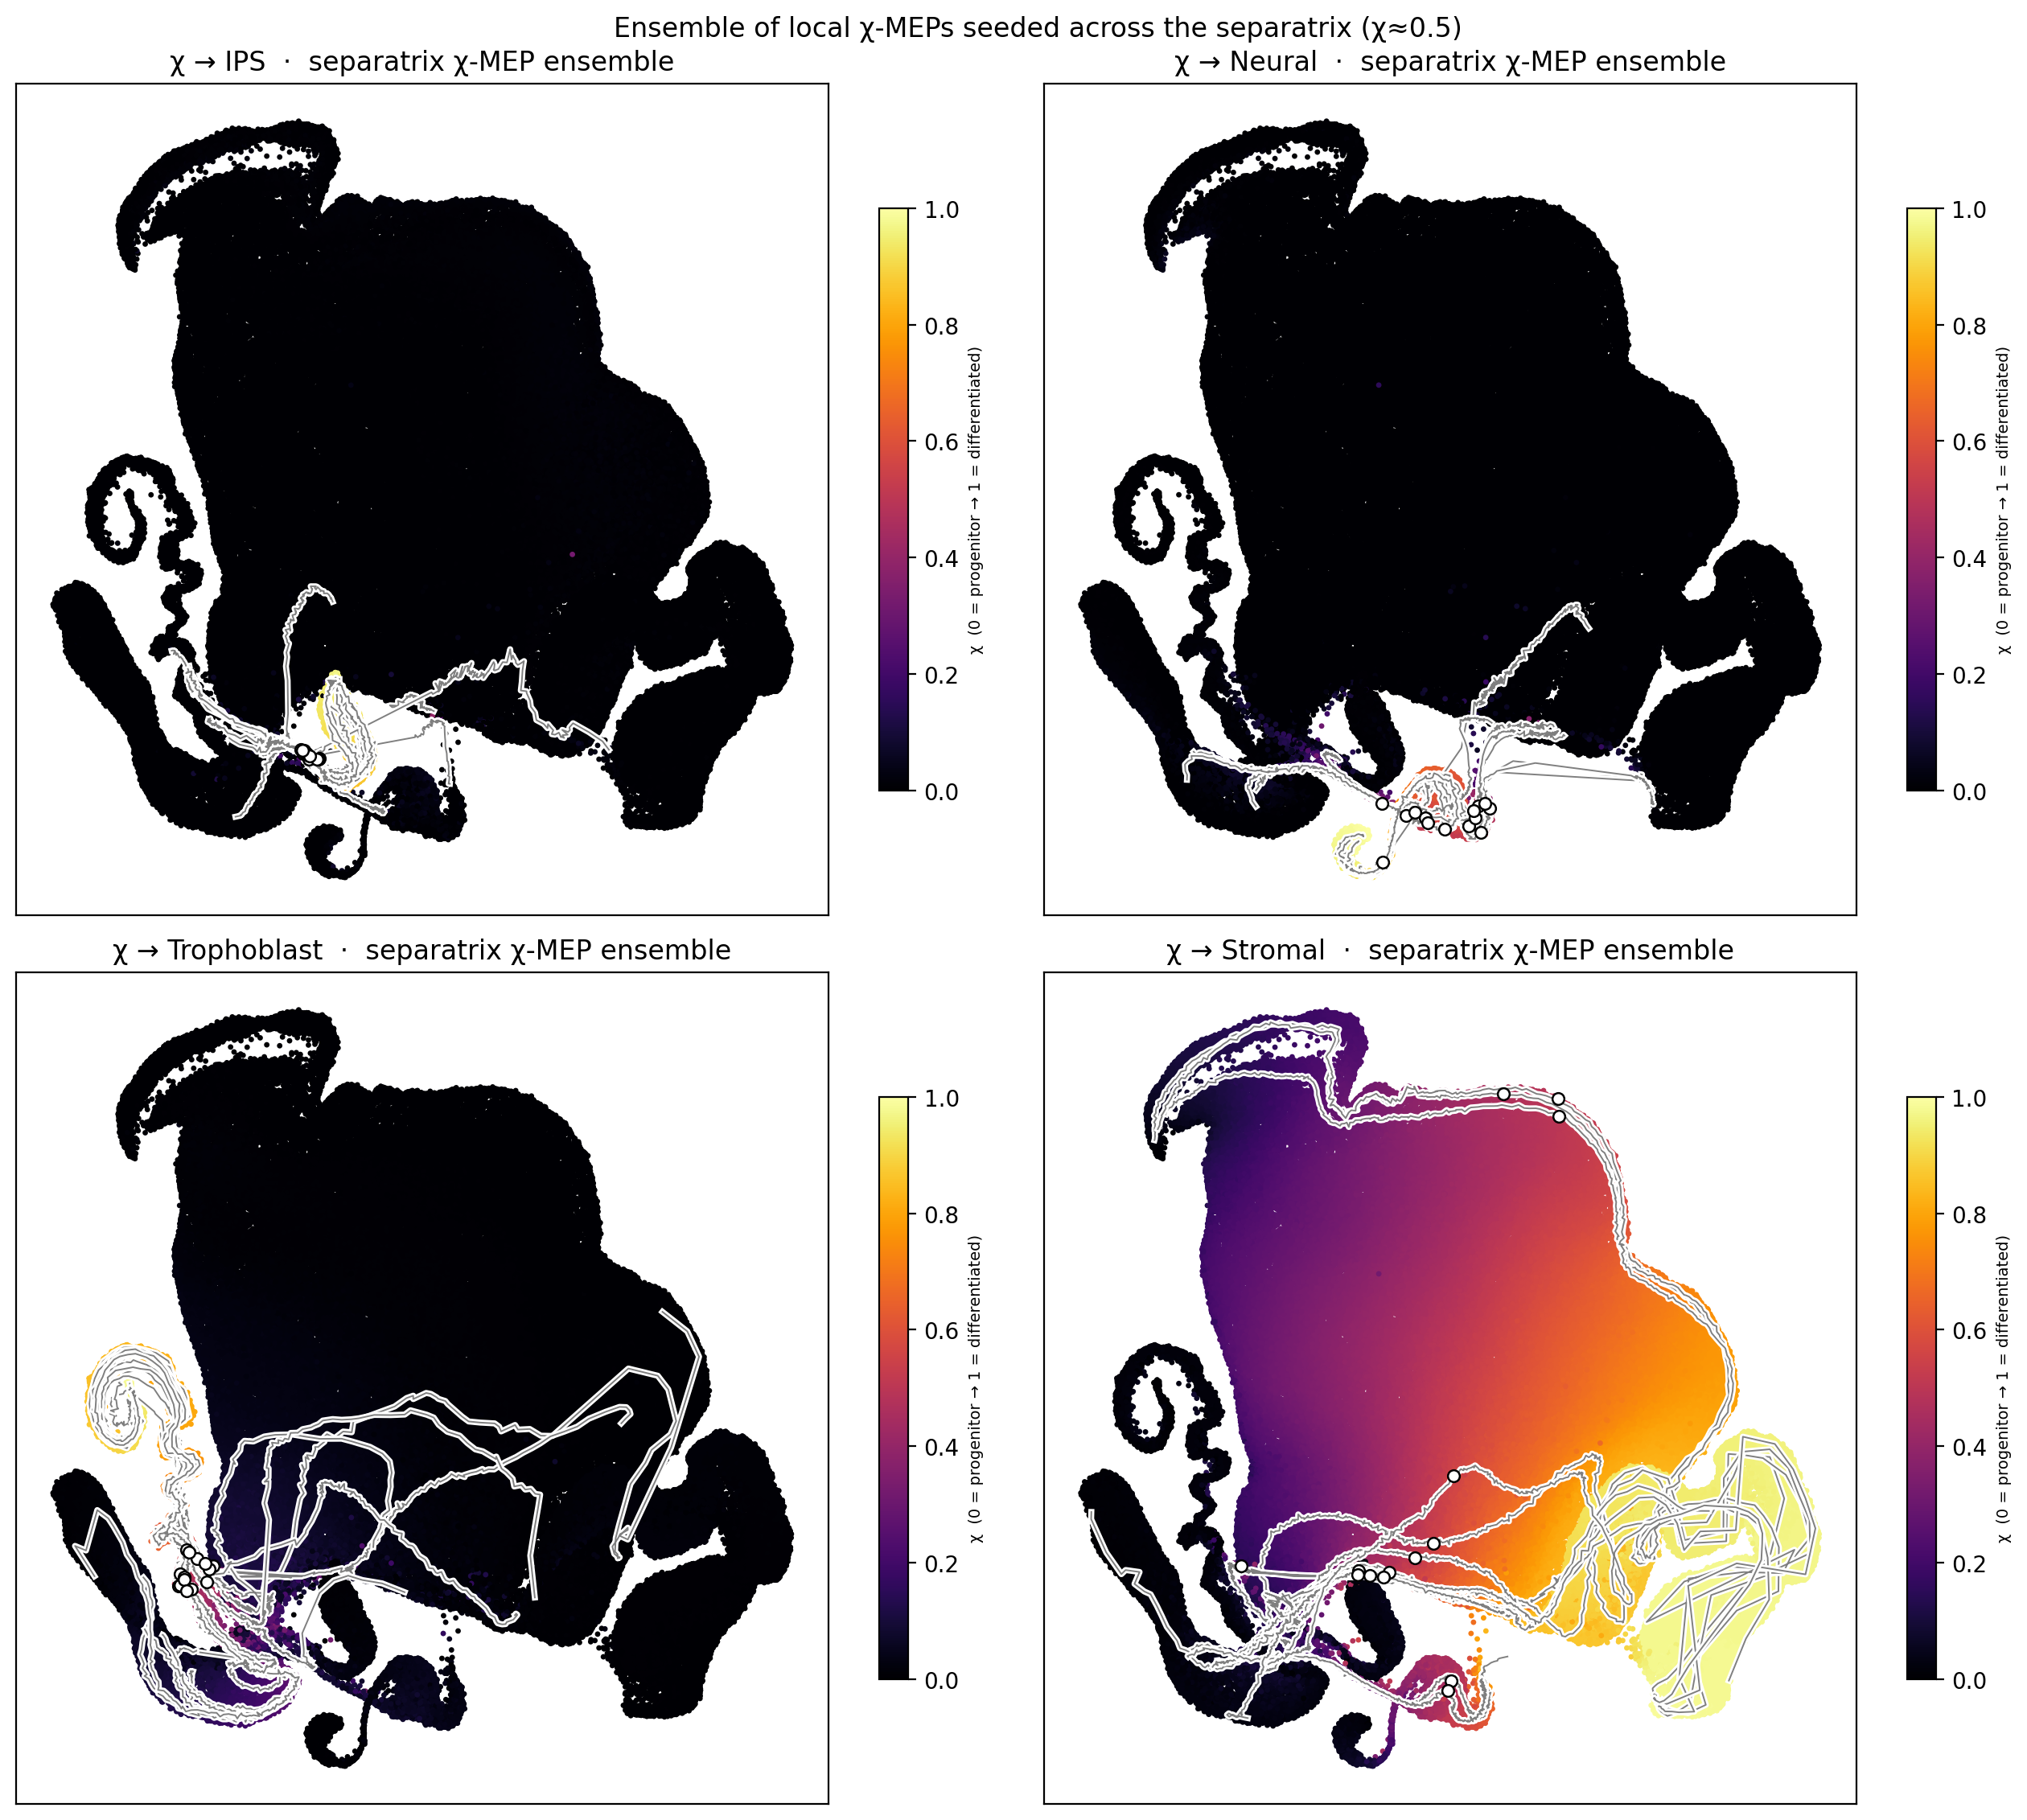

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11.5))
for ax, t in zip(axes.ravel(), TERMS):
    i = MAP[t]
    scatter_chi(ax, emb, chi[:, i], title=f"χ → {t}  ·  separatrix χ-MEP ensemble", s=6)
    for P in ens[t]["paths"]:
        e = project_to_chi_umap(net_pc, P, reducer)
        draw_path(ax, e, color="black", lw=0.7, alpha=0.5)
    s = ens[t]["seeds"]
    ax.scatter(emb[s, 0], emb[s, 1], facecolors="white", edgecolors="black", s=28, linewidths=0.9, zorder=8)
fig.suptitle("Ensemble of local χ-MEPs seeded across the separatrix (χ≈0.5)", fontsize=12)
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/panel_chimaps_mep_ensemble.png", dpi=600, bbox_inches="tight"); plt.show()

## 7 · Lineage driver heatmaps (top 30 χ-sensitivity genes)

For each lineage, the top-30 positive χ-sensitivity drivers shown as **χ-resolved mean expression**
(genes × 25 χ-bins, per-gene min–max normalised, viridis — positive-only, matching CR2's driver
convention). Genes hierarchically clustered; curated IPS markers green, TFs orange. Expression rises
coherently along the commitment axis the MEP traces.

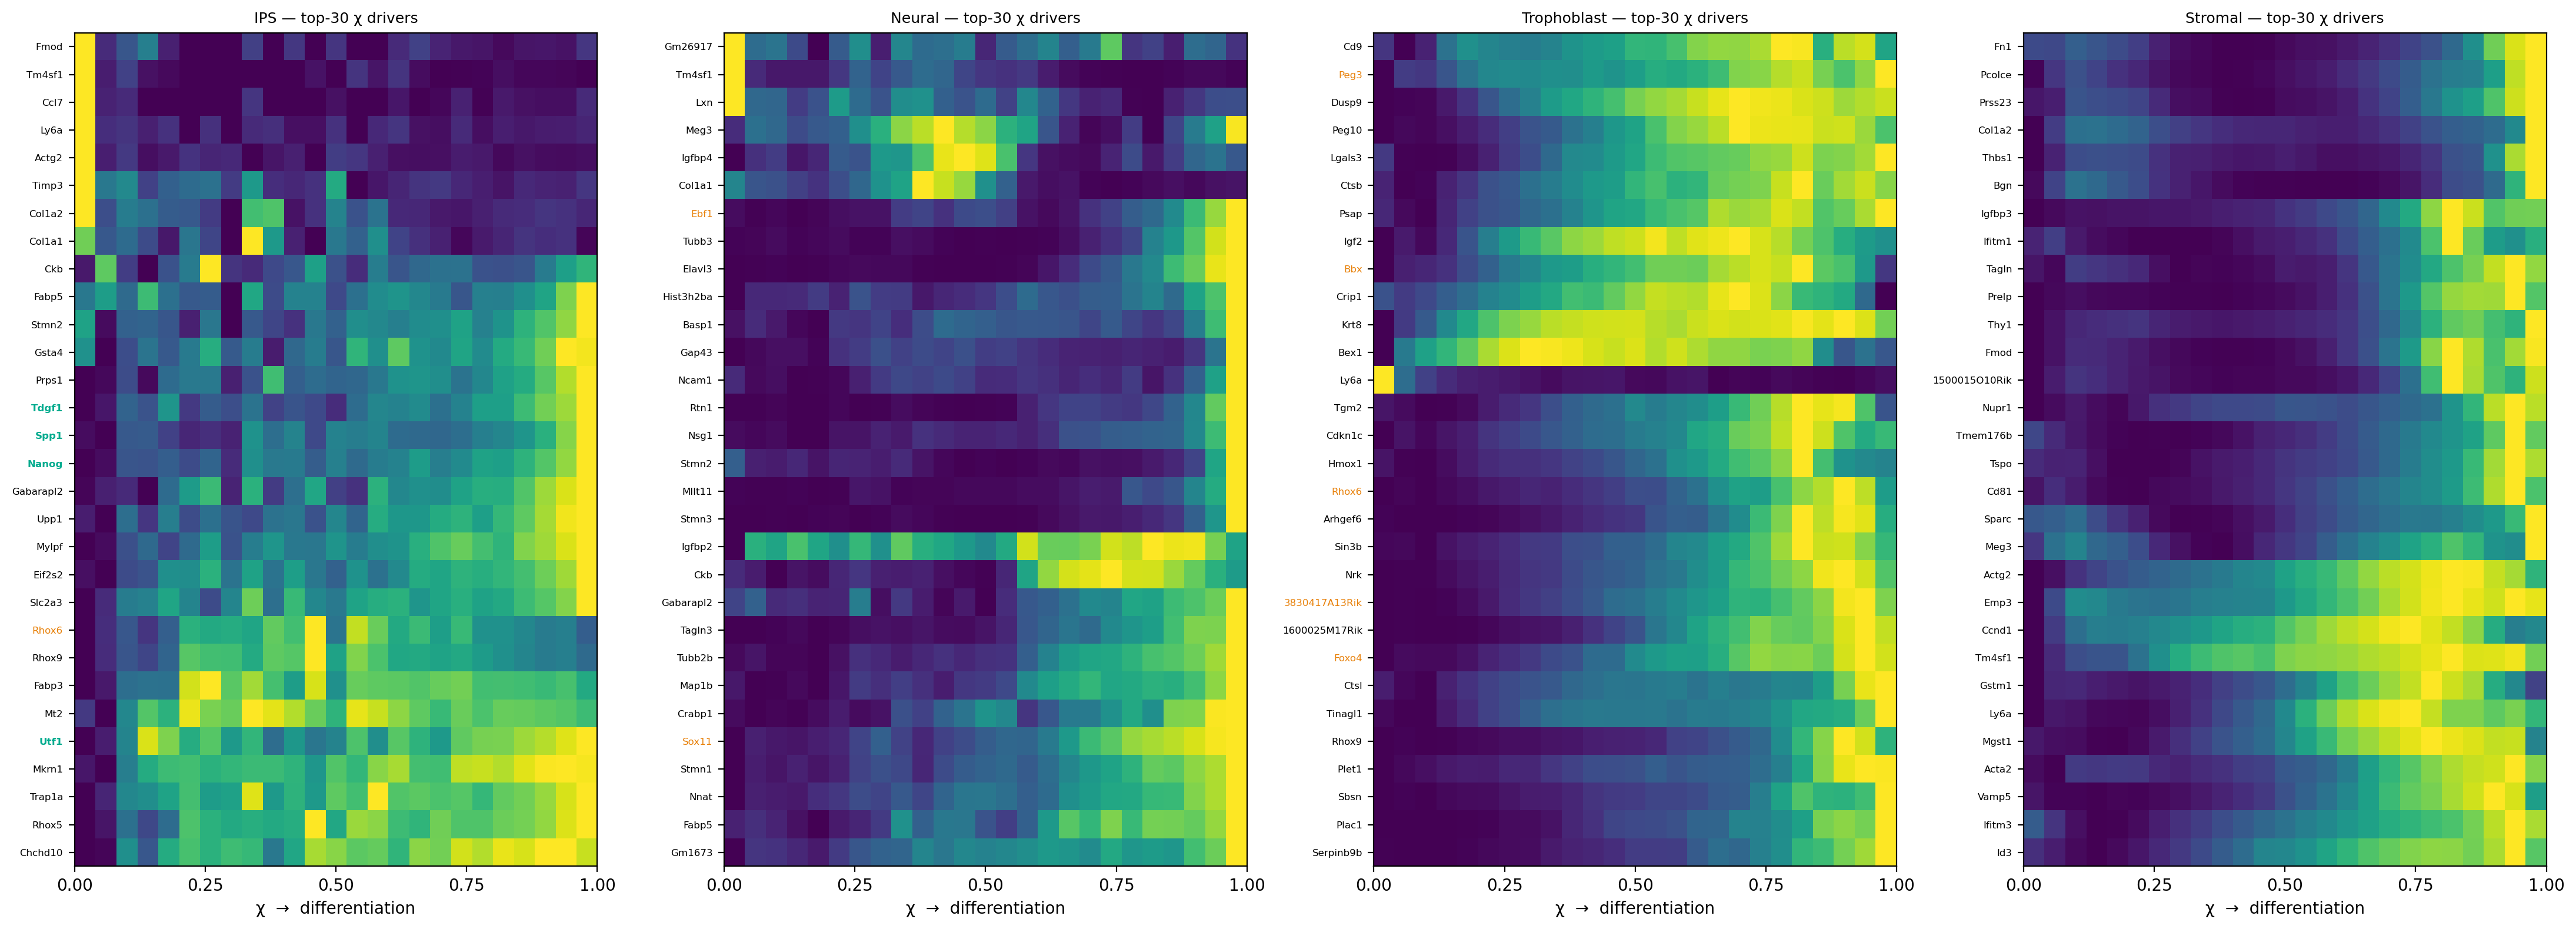

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(22, 8))
for ax, t in zip(axes, TERMS):
    g30 = top30[t]
    cols = np.array([np.where(genes_all == g)[0][0] for g in g30])
    expression_heatmap(ax, chi[:, MAP[t]], X_hvg[:, cols], g30,
                       nbins=25, tfs=tf_uni, curated=cur_uni, title=f"{t} — top-30 χ drivers")
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/heatmap_drivers.png", dpi=600, bbox_inches="tight"); plt.show()

## 8 · Curated IPS markers developing along χ (ground-truth validation)

Rather than the method's own top-ranked genes, this panel plots the **curated pluripotency/iPSC markers that
fall inside the gene universe** (a canonical literature panel; 10 of the 34 lie in the shipped 1479-HVG set) as
per-gene min–max-normalised mean expression along $\chi_{\text{IPS}}$ — the unsupervised commitment coordinate.
χ never saw these labels, so if the known markers switch on in a coherent **early→late order** as $\chi:0\to1$,
that is independent evidence χ is a genuine differentiation axis even where it underperforms GPCCA on the
sharp-classification metrics. Lines are coloured by activation order (viridis: early = dark, late = yellow),
sorted by the centre-of-mass of each profile in χ.

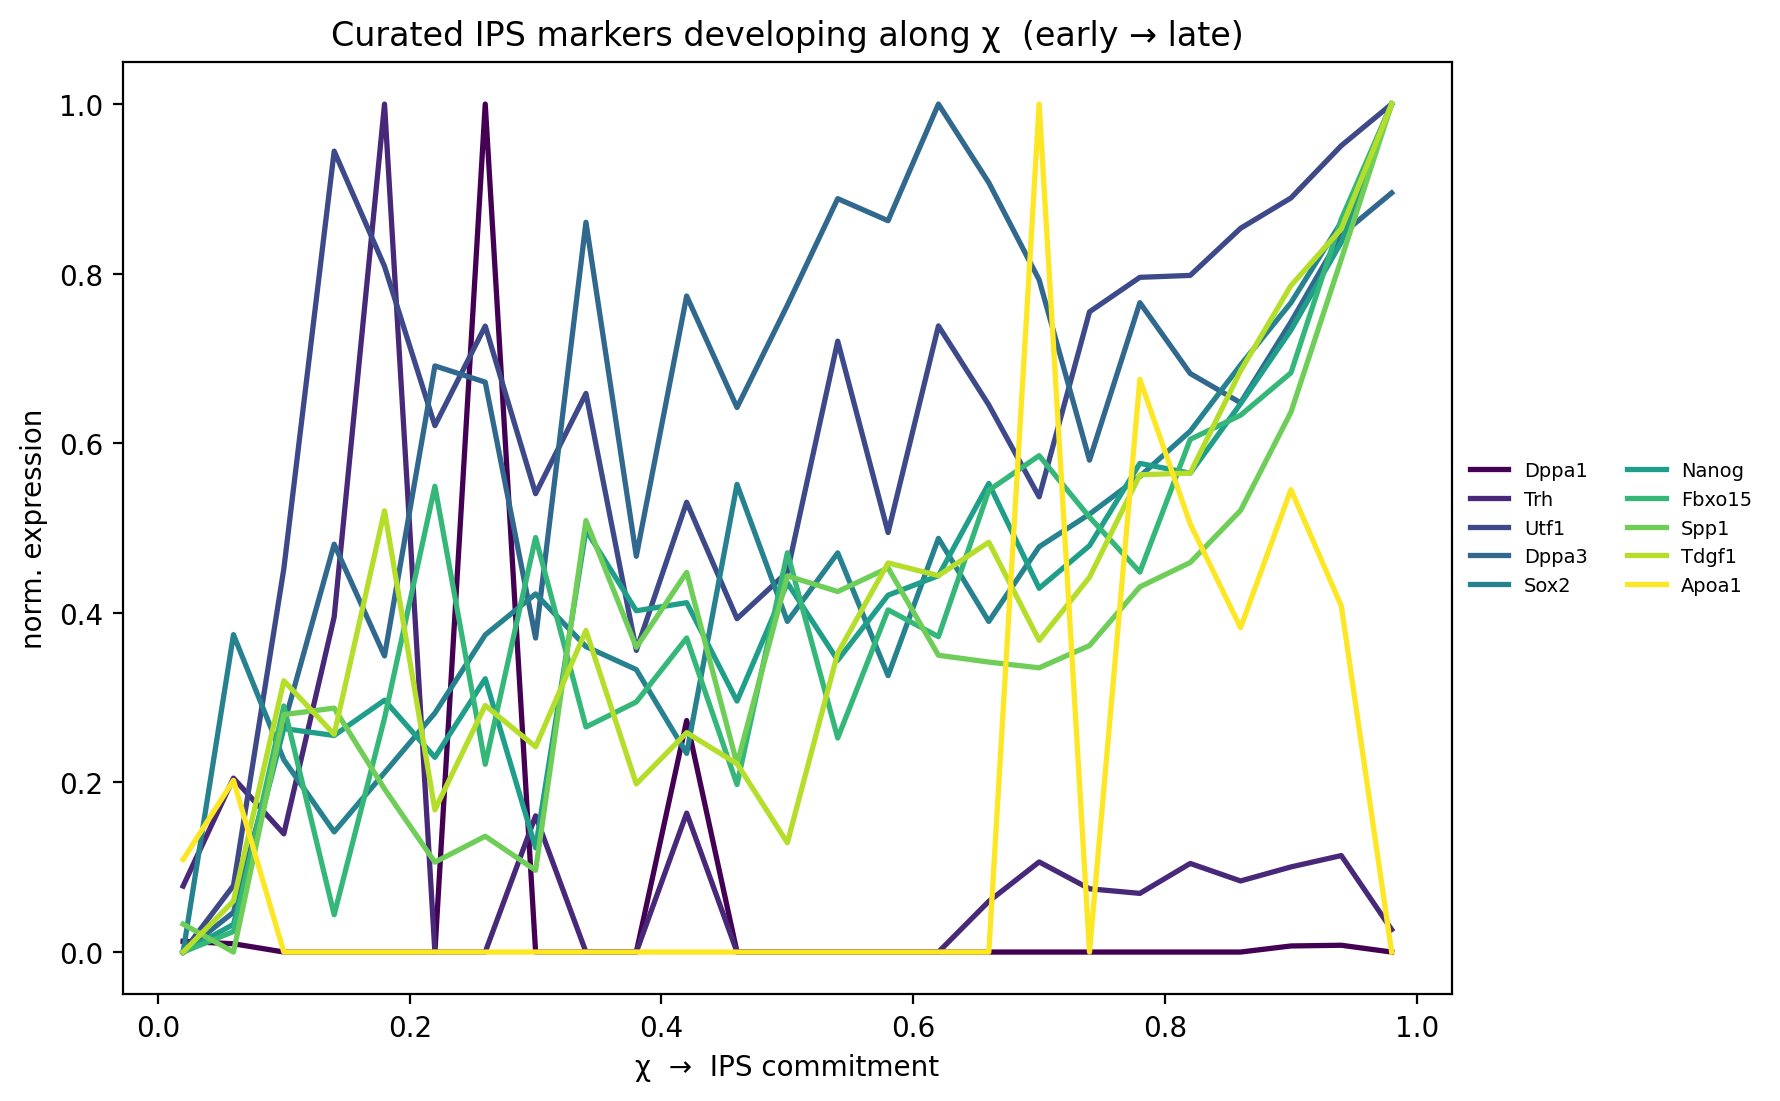

In [17]:
# 16 curated IPS markers present in the gene universe, expression along the IPS χ
ips = sorted(cur_uni)
cols = [int(np.where(genes_all == g)[0][0]) for g in ips]
chi_m = chi[:, MAP["IPS"]]
nbins = 25; edges = np.linspace(0, 1, nbins + 1); centres = 0.5 * (edges[:-1] + edges[1:])
binid = np.clip(np.digitize(chi_m, edges) - 1, 0, nbins - 1)
prof = np.full((len(ips), nbins), np.nan)
for b in range(nbins):
    m = binid == b
    if m.sum() >= 3:
        prof[:, b] = X_hvg[m][:, cols].mean(0)
mn = np.nanmin(prof, 1, keepdims=True); mx = np.nanmax(prof, 1, keepdims=True)
profn = (prof - mn) / (mx - mn + 1e-9)
# order genes by centre-of-mass of the normalised profile in χ (early -> late)
com = np.nansum(centres * profn, 1) / (np.nansum(profn, 1) + 1e-9)
order = np.argsort(com)
fig, ax = plt.subplots(figsize=(9, 5.6))
cmap = plt.get_cmap("viridis", len(order))
for rnk, j in enumerate(order):
    ax.plot(centres, profn[j], lw=1.9, color=cmap(rnk), label=ips[j])
ax.set_xlabel("χ  →  IPS commitment"); ax.set_ylabel("norm. expression")
ax.set_title("Curated IPS markers developing along χ  (early → late)")
ax.legend(fontsize=7, ncol=2, frameon=False, loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout(); fig.savefig(f"{C.FIGURES}/ips_curated_along_chi.png", dpi=600, bbox_inches="tight"); plt.show()

## 9 · Summary & conclusions

On the CellRank 2 **MEF reprogramming** benchmark, run with the *identical* pipeline as the pharyngeal-endoderm
analysis, with the χ dimension set from the Koopman spectrum (k=6, §1.5):

* **GPCCA reproduces CR2 exactly** — TSI = 1.0, all four macrostate/terminal-state purities = 1.0, and the
  force-directed embedding and fate probabilities match the published "mef" analysis (the GPCCA panels are the
  acceptance check, and they look as they should).
* **ISOKANN edges GPCCA on cell fate** (mean AUROC 0.995 vs 0.982): it beats GPCCA on Stromal (0.987 vs 0.937)
  and Trophoblast (0.998 vs 0.996), ties Neural (1.000), and is a hair behind on the rare IPS branch (0.995 vs
  0.997, though IPS top-30 purity = 1.0). Mean top-30 purity ~0.93 (1.0 on three lineages; one ~0.73–0.83 — a
  brittle-metric artifact, see §5).
* **ISOKANN is competitive-to-better on lineage drivers**: the **corr-χ** readout has the highest recovery-AUC
  of all methods (0.550 vs GPCCA 0.525), and every ISOKANN readout recovers curated IPS @100 = 7 (vs GPCCA's 6)
  — the same "the readout, not the representation, is the bottleneck" result as on the pharynx.

**The decisive lesson — set the ISOKANN state count from the operator, not the label count.** A first run at
**k=4** (naively matching CR2's pinned 4 macrostates) was *wrong*: with no membership for the dominant
non-metastable `MEF/other` source, the column Hungarian-labelled "IPS" was in fact the source (its top cells
were ~100% MEF/other), IPS fate AUROC was only 0.879, the χ-binned driver recovery was 1/10, and the ISA loss
spiked. The Koopman spectrum is unambiguous — six eigenvalues near 1 (the Perron λ=1 plus five slow processes)
then a 0.025 gap. Because the ISA χ are partition-of-unity *memberships*, the right count is the number of
dominant eigenvalues **including** the constant (= 6), not the number of nontrivial committors (5): the constant
is the memberships' sum, not a discarded mode. Training **k=6** and mapping the four terminals by Hungarian
assignment de-lumps IPS, removes the loss pathology, and flips every aggregate in ISOKANN's favour. (A
side-by-side **k=4 comparison notebook** is provided so the failure mode is documented, not hidden.)

**The one weak spot:** the 1479-HVG model does not train cleanly at k=6 (two memberships collapse under the
lighter HVG schedule), so the 50-PC model is the ISOKANN representative throughout. Method choices are otherwise
unchanged from the pharyngeal analysis (local χ-MEP for pathways; χ-binned averaged gradient + corr-χ for
drivers; viridis positive-only χ-resolved expression for heatmaps; raw-medoid path with no spline; the ensemble
χ-MEP attribution binned-and-averaged along the pathways, never path-integrated). The deployed χ is the best
iterate of the (noisy) ISA training; everything is computed live from the *same* published RealTimeKernel
transition matrix CR2 uses.